## **Project Type: Senior Graduation Project2**
**Project Name:** RASID (راصد)  
**Focus:** Predictive Maintenance for Railway Systems (Engine Failures)  
**Partner:** Saudi Railway Company (SAR)

---

## **Key Achievements**

- Developed a functional **two-stage predictive system**:
  - **Stage 1**: A binary classification model that predicts whether a failure is likely to occur or not.
  - **Stage 2**: A multi-class model that identifies **which specific type of failure** is occurring, if Stage 1 detects a potential failure.
- Integrated an **early degradation detection mechanism**, enabling maintenance teams to take proactive action before serious damage occurs.


#All Imports

In [ ]:
# Core Libraries
import pandas as pd
import numpy as np
import os
import math
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from zipfile import ZipFile

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, label_binarize
from sklearn.utils import shuffle, resample
from sklearn.model_selection import train_test_split

# Metrics and Evaluation
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score,
    f1_score, precision_score, recall_score,
    roc_curve, auc
)

# Deep Learning - Keras (LSTM & GRU)
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Bidirectional, LSTM, GRU, Dense, Dropout,  Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam,  RMSprop, Nadam
import tensorflow as tf
from tensorflow.keras.losses import MeanSquaredError


# Tree-Based Models
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor



## **Dataset Structure and Initial Overview**

The original dataset contains a total of **113 features** (columns), including timestamp information and various sensor readings. These features include:

- **50 float64 features** (continuous numerical values)
- **46 int64 features** (discrete numerical values)
- **17 object features** (mostly categorical or string-based)

In the next steps, we will:
1. **Handle the dataset as a whole**, exploring the structure and understanding the content.
2. Proceed with **group-specific handling** of certain features (e.g., sensor groupings, timestamps, etc.).
3. Perform **data cleaning and transformation** as needed to prepare the data for modeling.


# **Step 1: Data Read and Merge**

In [3]:
zip_path = "/content/Corrected_Failure_Files.zip"

with ZipFile(zip_path, 'r') as zipf:
    file_names = [f for f in zipf.namelist() if f.endswith('.xlsx')]

    with zipf.open(file_names[0]) as f:
        merged_data = pd.read_excel(f)
        common_columns = set(merged_data.columns)

    for file in file_names[1:]:
        with zipf.open(file) as f:
            df = pd.read_excel(f, nrows=1)
            common_columns &= set(df.columns)

    common_columns = list(common_columns)

    dataframes = []
    for file in file_names:
        with zipf.open(file) as f:
            df = pd.read_excel(f, usecols=common_columns)
            dataframes.append(df)

            empty_row = pd.DataFrame([[0]*len(common_columns)], columns=common_columns)
            dataframes.append(empty_row)

merged_data = pd.concat(dataframes, ignore_index=True)
merged_data.to_csv("merged_output.csv", index=False)

print(merged_data.head())


            Time Stamp Sample  Description Asset Name  Order Number Data Pack  \
0  2024-05-10 01:38:54               Power   SAR 4005      20088067        NO   
1  2024-05-10 02:06:25               Power   SAR 4005      20088067        NO   
2  2024-05-10 06:04:02               Power   SAR 4005      20088067        NO   
3  2024-05-10 07:50:03               Power   SAR 4005      20088067        NO   
4  2024-05-13 15:05:53               Power   SAR 4005      20088067        NO   

   DataPack Number  AmbTmpF  APCcLb  APImRbP  ATImRbF  ...  TmIj15  TmIj16  \
0              NaN     38.6   -1.13   206.84     70.0  ...    1.33    1.33   
1              NaN     42.7   -1.13   224.08     70.0  ...    1.34    1.34   
2              NaN     38.2   -1.25   213.74     70.0  ...    1.34    1.34   
3              NaN     39.8   -1.25   217.18     71.1  ...    1.34    1.34   
4              NaN     33.7   -1.13   193.05     70.0  ...    1.33    1.33   

   TnSt  TPU RPM  WDTM1  WDTM2 WPEgILP WPEgO

In [4]:
df = merged_data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4849 entries, 0 to 4848
Columns: 113 entries, Time Stamp to failure_type
dtypes: float64(50), int64(46), object(17)
memory usage: 4.2+ MB


In [5]:
df_original = df.copy()

# **Step 2: EDA**

## Data Cleaning: Missing Values and Duplicate Columns

Before proceeding with modeling, we apply essential data cleaning steps to improve data integrity and quality.

### 1. Handling Missing Values

We begin by checking for missing values in the dataset using both numerical summaries and a heatmap visualization.

- A heatmap was used to visually inspect null distributions.
- Features with consistent or irrelevant missingness (e.g., `'DataPack Number'`, `'Order Number'`) were dropped entirely.

These columns were found to have either no contribution to model performance or contained fully missing entries.

### 2. Identifying and Removing Duplicate Columns

We check for two types of duplicates:

- **Column-wise duplicates**: Two or more columns that contain exactly the same values.
- **Near-identical features**: Features with the same distribution or structure, e.g., multiple sensor readings from mirrored positions.

Examples:
- Columns like `'ICCCG'`, `'ICCGG'`, `'TCSTAF'`, and `'TCSTAF1'` were found to be redundant and were removed.
- Redundant binary flags (0/1 with no variance) were also removed where applicable.

These steps help reduce noise, lower model complexity, and eliminate multicollinearity from structurally redundant features.


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order Number,4849.0,1.997564e+07,1.602700e+06,0.0,2.008807e+07,2.008807e+07,2.014805e+07,2.014805e+07
DataPack Number,31.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
AmbTmpF,4849.0,3.764871e+01,9.529337e+00,0.0,3.040000e+01,3.760000e+01,4.510000e+01,6.260000e+01
APCcLb,4849.0,-7.600577e-01,4.841267e-01,-3.0,-1.000000e+00,-6.300000e-01,-5.000000e-01,7.500000e-01
APImRbP,4849.0,2.626195e+02,3.888133e+01,0.0,2.413200e+02,2.637200e+02,2.930300e+02,3.292200e+02
...,...,...,...,...,...,...,...,...
TPU RPM,4849.0,1.866712e+04,2.176634e+03,0.0,1.809700e+04,1.895200e+04,1.962000e+04,2.118800e+04
WDTM1,4849.0,1.046491e+00,8.975533e-02,0.0,1.036000e+00,1.067000e+00,1.067000e+00,1.125000e+00
WDTM2,4849.0,1.046330e+00,8.959727e-02,0.0,1.036000e+00,1.067000e+00,1.067000e+00,1.124000e+00
WPEgILP,4849.0,3.850085e+02,4.985175e+01,0.0,3.551000e+02,3.861000e+02,4.171000e+02,4.964000e+02


1. Check Missing Value

In [7]:
df.isnull().sum().sum()

np.int64(4818)

<Axes: >

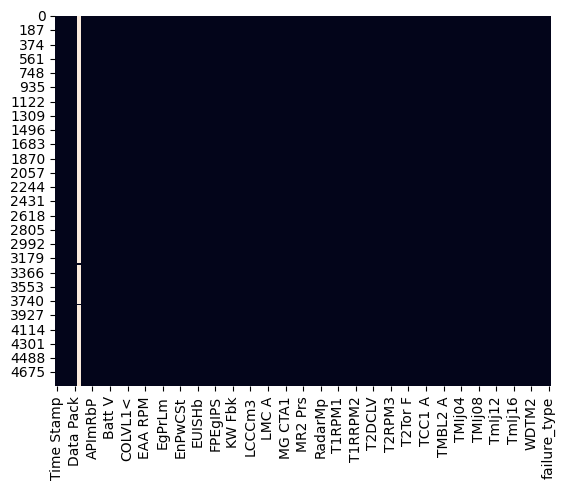

In [8]:
sns.heatmap(df.isnull(), cbar=False)

In [9]:
df.drop(columns=['DataPack Number'], inplace=True)

In [10]:
df.drop(columns=['Order Number'] , inplace=True)

2. Check Duplicates

In [11]:
df.duplicated().sum()

np.int64(33)

In [12]:
duplicate_cols = []

for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        col1 = df.columns[i]
        col2 = df.columns[j]
        if df[col1].equals(df[col2]):
            duplicate_cols.append((col1, col2))

for pair in duplicate_cols:
    print(f"{pair[0]} ≡ {pair[1]}")


LCCCm4 ≡ LCCCm5
TC1STAT ≡ TC2STAT


In [13]:
df.drop(columns=['LCCCm5','LCCCm3','TC2STAT'], inplace=True)

In [14]:
cols_to_drop = [
    col for col in df.columns
    if df[col].nunique(dropna=True) == 2 and (0 in df[col].unique())
]

for col in cols_to_drop:
    print(f"➔ {col}")
df = df.drop(columns=cols_to_drop)

➔ Sample  Description
➔ Data Pack
➔ EgPrLmR
➔ LCCCm4
➔ MtrsAvl


See Classes Distrbuation Before Any Preprocess Step

## **Target Variable: Class Distribution Analysis**

Before applying any preprocessing or modeling steps, we examine the distribution of the target variable `failure_type`. This feature represents the type of failure that occurred in a given engine instance, or `"no failure"` if the engine operated normally.

As shown in the distribution plot and value counts output, the dataset is **highly imbalanced**. The majority class is `'no failure'` with **4787 instances**, while the remaining failure classes are represented by only a few samples:

- `turbocharger`: 9 instances  
- `power_assembly`: 8 instances  
- `SRS_TRS`: 7 instances  
- `injector`: 7 instances  
- `0` (ambiguous/placeholder): 31 instances  

> **Note:** The `'0'` class was introduced during the merging process to serve as a **separator between engine logs**. These rows were added intentionally and do not represent real failure events.

This significant imbalance is clearly visible in the count plot, where the `'no failure'` class dominates the dataset. Such skewed class distributions must be addressed during model development to prevent the model from being biased toward the majority class.  
Appropriate techniques to handle this issue will be introduced later in the notebook.


failure_type
no failure        4787
0                   31
turbocharger         9
power_assembly       8
SRS_TRS              7
injector             7
Name: count, dtype: int64


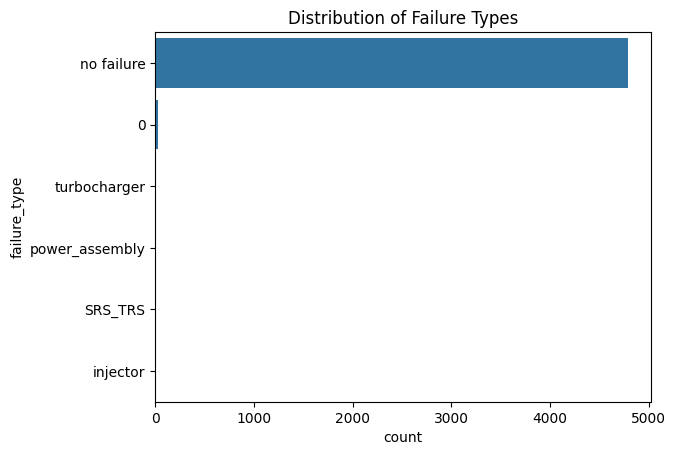

In [15]:
print(df['failure_type'].value_counts())
sns.countplot(y='failure_type', data=df, order=df['failure_type'].value_counts().index)
plt.title("Distribution of Failure Types")
plt.show()

## **Understanding and Processing Categorical (Object) Features**

In this step, we analyze the object-type (categorical) features present in the dataset. These features typically include status indicators, sensor modes, or device configurations recorded as text.

### Step 1: Overview of Object Features
We begin by listing all columns with `object` data types and previewing a few rows to understand their nature. Features such as `Fan 1`, `EDUP`, `MG Stat`, and others contain state values like `"ON"`, `"OFF"`, or categorical indicators such as `"FULL"`, `"CS"`, etc.

We also compute the unique value counts for each object column. This helps us identify:
- Features with a large number of unique values (possibly IDs or non-informative).
- Features with low variation (e.g., one dominant category across rows).

### Step 2: Feature Selection Based on Correlation

To determine which categorical features are informative for predicting failure, we examine their relationship with the `failure_type` column using **heatmaps of normalized crosstabulations**. This visual method helps detect features that have distinct distributions across different failure classes.

From this analysis, we drop features that show no useful variation or weak/no correlation with the target. Examples of dropped features include:
- `COLSV1`, `COLSV2`, `MG Stat`, `TC1STAT`, etc.

These features were either redundant, irrelevant, or uniformly distributed across all rows (i.e., having no predictive power).

### Step 3: Result

After this filtering step, the dataset retains only the most relevant object features, and the remaining features are either numeric or structured for encoding.


Here we want to see the features thet are object to understand them

In [16]:
object_cols = df.select_dtypes(include='object')
object_cols.head(10)

,Time Stamp,Asset Name,COLSYST,COLVL1<,COLVL2<,EnPwCSt,Fan 1,Fan 2,LdUnit<,MG Stat,MVCC>,TC1STAT,WS Stat,failure_type
0,2024-05-10 01:38:54,SAR 4005,Full,ON,ON,EOLP,OFF,FULL,OFF,TCCV,ON,EOLP,CS,no failure
1,2024-05-10 02:06:25,SAR 4005,Full,ON,ON,EOLP,OFF,FULL,OFF,TCCV,ON,EOLP,CS,no failure
2,2024-05-10 06:04:02,SAR 4005,Full,ON,ON,EOLP,FULL,FULL,OFF,TCCV,OFF,EOLP,CS,no failure
3,2024-05-10 07:50:03,SAR 4005,Full,ON,ON,EOLP,FULL,FULL,OFF,TCCV,ON,EOLP,CS,no failure
4,2024-05-13 15:05:53,SAR 4005,Full,ON,ON,EOLP,FULL,OFF,OFF,TCCV,ON,EOLP,CS,no failure
5,2024-05-13 22:39:27,SAR 4005,Full,ON,ON,EOLP,HALF,OFF,OFF,TCCV,ON,EOLP,CS,no failure
6,2024-05-14 00:26:59,SAR 4005,Full,ON,ON,EOLP,OFF,FULL,OFF,TCCV,ON,EOLP,CS,no failure
7,2024-05-14 02:06:00,SAR 4005,Full,ON,ON,EOLP,FULL,OFF,OFF,TCCV,ON,EOLP,CS,no failure
8,2024-05-14 02:30:01,SAR 4005,Full,ON,ON,EOLP,FULL,FULL,OFF,TCCV,ON,EOLP,CS,no failure
9,2024-05-14 05:38:03,SAR 4005,Full,ON,ON,EOLP,FULL,FULL,OFF,TCCV,OFF,EOLP,CS,no failure


In [17]:
object_cols = df.select_dtypes(include='object')
unique_object_counts = object_cols.apply(lambda col: col[col != "0"].nunique())
print(unique_object_counts)

Time Stamp      4806
Asset Name        22
COLSYST            5
COLVL1<            3
COLVL2<            3
EnPwCSt           10
Fan 1              4
Fan 2              4
LdUnit<            3
MG Stat            4
MVCC>              3
TC1STAT           11
WS Stat            3
failure_type       6
dtype: int64


Correlation to decide how to deals with objects

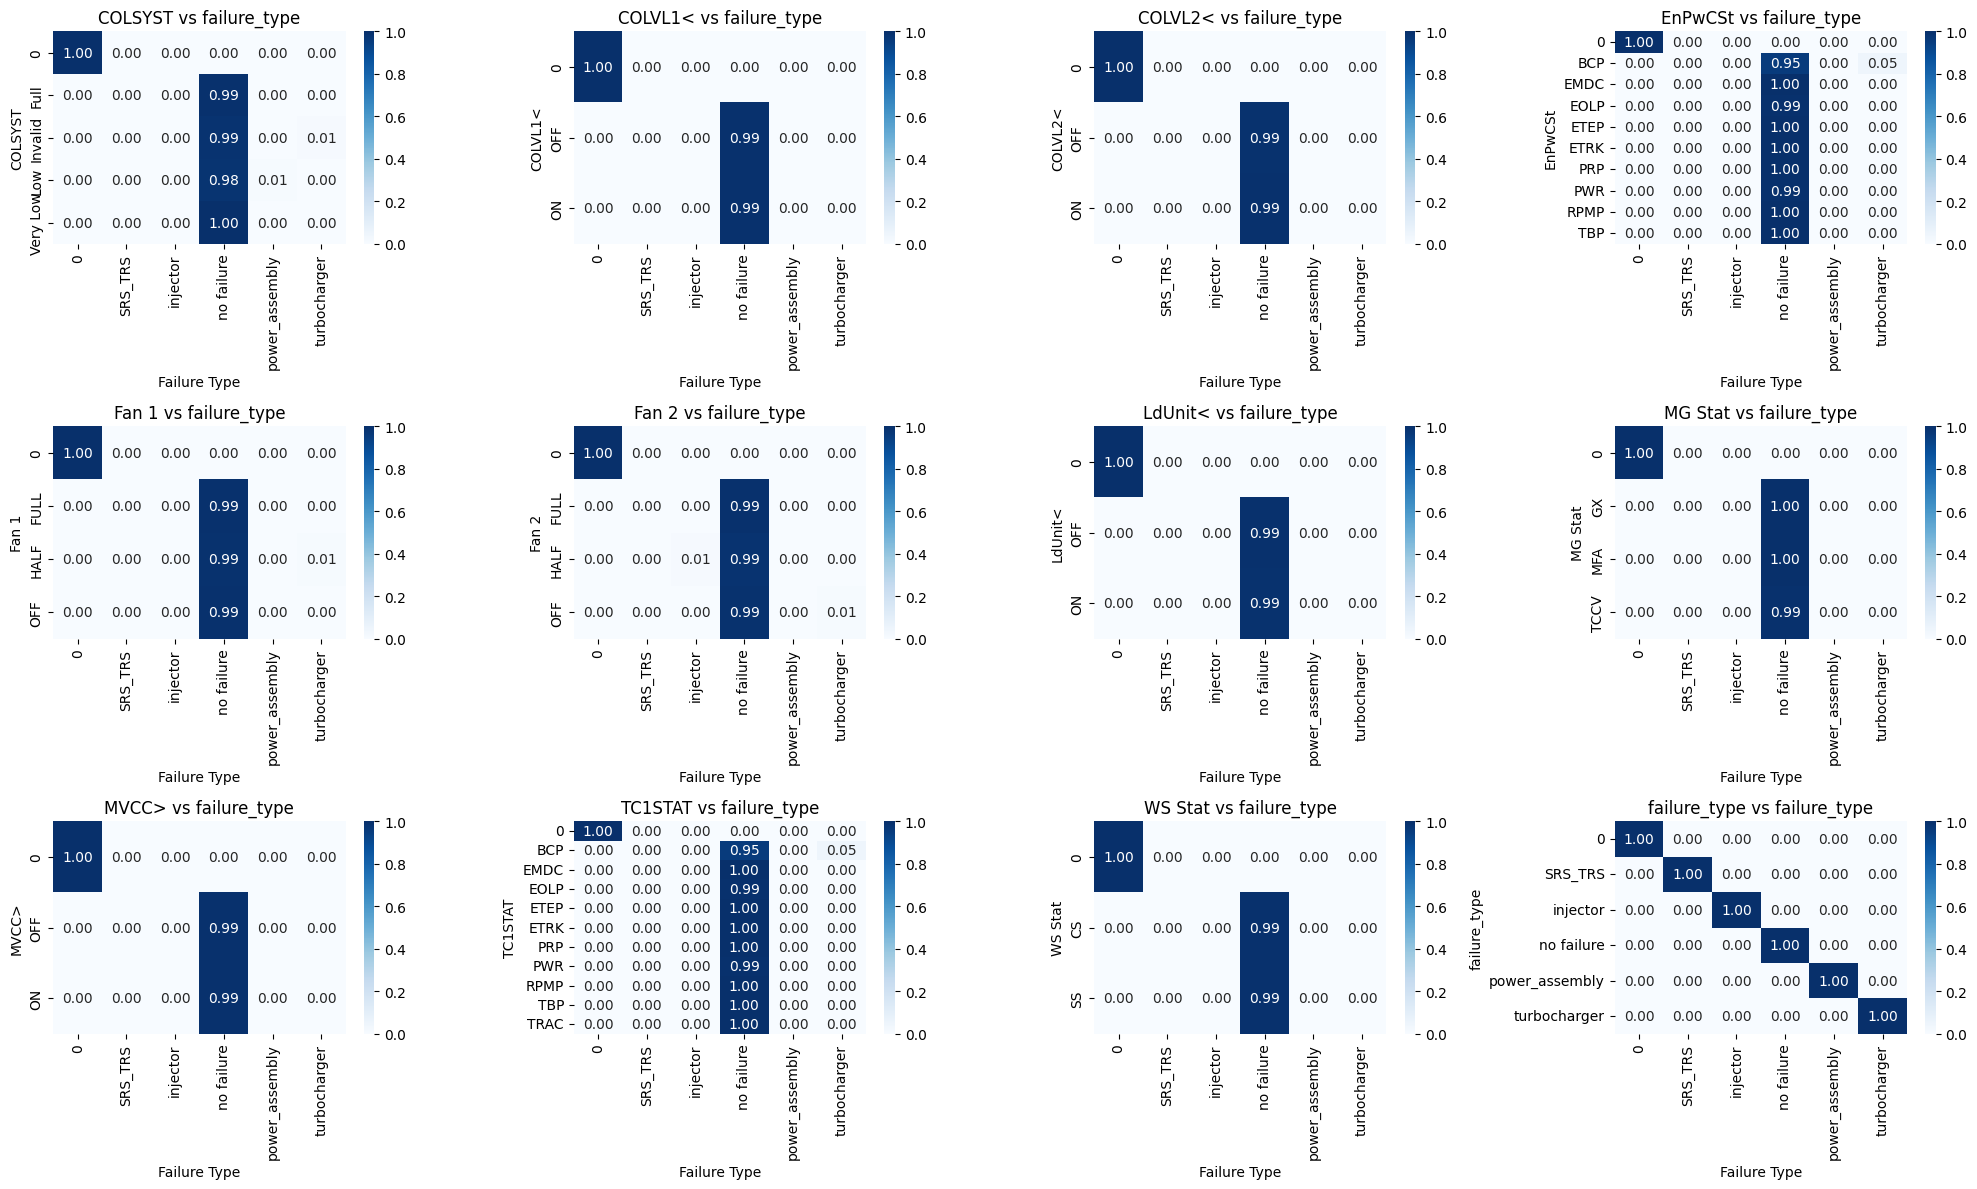

In [18]:
exclude_cols = ['Time Stamp', 'Asset Name']
object_cols_filtered = object_cols.drop(columns=exclude_cols, errors='ignore')

n_cols = 4
n_rows = math.ceil(len(object_cols_filtered.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(object_cols_filtered.columns):
    filtered_df = df[df[col] != "0"]
    ctab = pd.crosstab(filtered_df[col], filtered_df['failure_type'], normalize='index')

    sns.heatmap(ctab, annot=True, cmap="Blues", cbar=True, fmt=".2f", ax=axes[idx])
    axes[idx].set_title(f"{col} vs failure_type")
    axes[idx].set_xlabel("Failure Type")
    axes[idx].set_ylabel(col)

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [19]:
cols_to_drop = [
    'Sample Description', 'Data Pack', 'COLSYST', 'COLVL1<', 'COLVL2<',
    'EnPwCSt', 'Fan 1', 'Fan 2', 'LdUnit<', 'MG Stat', 'MVCC>',
    'TC1STAT', 'TC2STAT', 'WS Stat'
]

df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore', inplace=True)

Data After Dropped Features (Objects)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4849 entries, 0 to 4848
Data columns (total 92 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Time Stamp    4849 non-null   object 
 1   Asset Name    4849 non-null   object 
 2   AmbTmpF       4849 non-null   float64
 3   APCcLb        4849 non-null   float64
 4   APImRbP       4849 non-null   float64
 5   ATImRbF       4849 non-null   float64
 6   AWTF          4849 non-null   float64
 7   Bar Prs       4849 non-null   float64
 8   Batt V        4849 non-null   float64
 9   CA V          4849 non-null   float64
 10  ChpDty        4849 non-null   float64
 11  DCL1V         4849 non-null   int64  
 12  DCL2V         4849 non-null   int64  
 13  EAA RPM       4849 non-null   int64  
 14  EEngRPM       4849 non-null   int64  
 15  EgAirTF       4849 non-null   float64
 16  EgOilTF       4849 non-null   float64
 17  EgPrLm        4849 non-null   int64  
 18  Eng RPM       4849 non-null 

### Remaining Object Features After Cleaning

Following the removal of redundant and irrelevant columns, we examined the remaining categorical or string-based (`object`) features.

Currently, only **3 object-type columns** remain in the dataset:
- `Time Stamp`: A timestamp column indicating when each record was collected.
- `Asset Name`: The identifier or name of the engine unit.
- `failure_type`: The target variable indicating the failure category.

These columns will either be transformed (e.g., label encoding for `failure_type`) or excluded from numerical modeling if not suitable.


In [21]:
object_columns = df.select_dtypes(include='object').columns.tolist()

print(f"(object): {len(object_columns)}")

print(object_columns)

(object): 3
['Time Stamp', 'Asset Name', 'failure_type']


## **Understanding and Processing Numerical Features**

The dataset contains a large number of numerical features derived from sensor readings. To ensure model reliability and efficiency, we perform a detailed analysis and reduction of these features.

### Step 1: Correlation Analysis

We begin by generating a Pearson correlation matrix between all numerical features. The heatmap below visualizes these relationships, highlighting strongly correlated pairs.

- High correlation values (close to 1 or -1) between features indicate potential redundancy.
- Strongly correlated features may introduce multicollinearity, affecting model interpretability and performance.

### Step 2: Removing Highly Correlated Features

To address redundancy, we remove one feature from each pair whose correlation exceeds a defined threshold (**0.99** in our case). This process helps:
- Eliminate duplicate signals.
- Simplify the feature space.
- Improve generalization during model training.

As a result, the feature set is reduced from **113 to 65 features**, keeping only the most informative variables.

### Step 3: Summary of Cleaned Data

After dropping redundant features, we display the updated data structure using `df.info()` to verify the column count and datatypes.


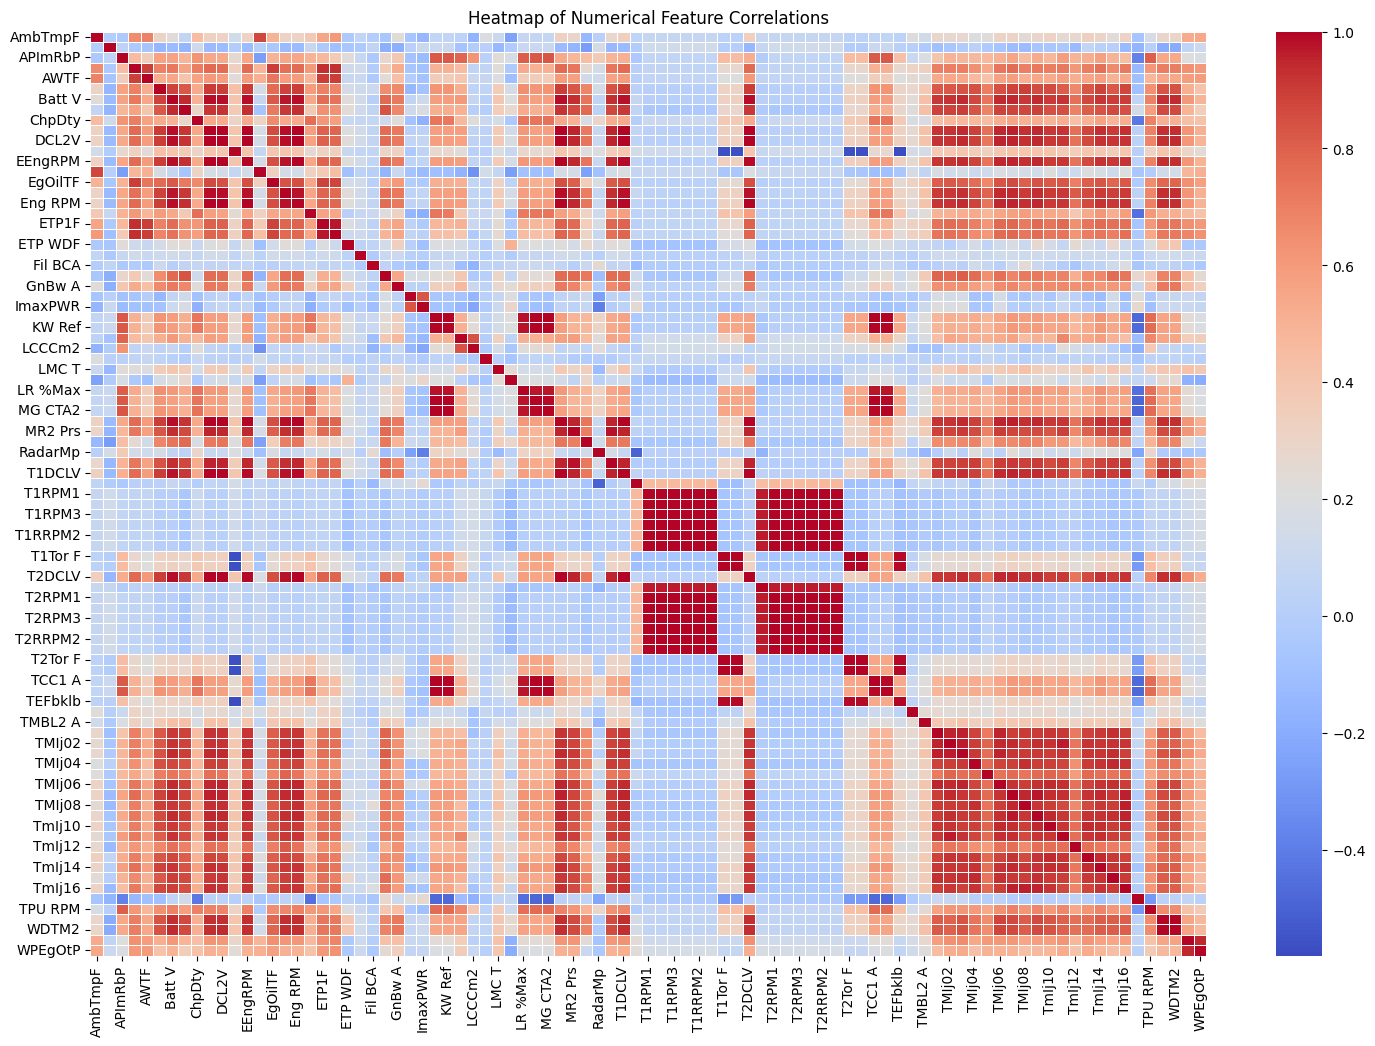

In [22]:
numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(18, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap of Numerical Feature Correlations")
plt.show()


In [23]:
threshold = 0.99
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
print(to_drop)
df = df.drop(columns=to_drop)


['DCL2V', 'EEngRPM', 'Eng RPM', 'KW Ref', 'MG CTA1', 'MG CTA2', 'MG V', 'T1DCLV', 'T1RPM2', 'T1RPM3', 'T1RRPM1', 'T1RRPM2', 'T1RRPM3', 'T1Tor R', 'T2DCLV', 'T2RPM1', 'T2RPM2', 'T2RPM3', 'T2RRPM1', 'T2RRPM2', 'T2RRPM3', 'T2Tor F', 'T2Tor R', 'TCC1 A', 'TCC2 A', 'TEFbklb', 'WDTM2']


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4849 entries, 0 to 4848
Data columns (total 65 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Time Stamp    4849 non-null   object 
 1   Asset Name    4849 non-null   object 
 2   AmbTmpF       4849 non-null   float64
 3   APCcLb        4849 non-null   float64
 4   APImRbP       4849 non-null   float64
 5   ATImRbF       4849 non-null   float64
 6   AWTF          4849 non-null   float64
 7   Bar Prs       4849 non-null   float64
 8   Batt V        4849 non-null   float64
 9   CA V          4849 non-null   float64
 10  ChpDty        4849 non-null   float64
 11  DCL1V         4849 non-null   int64  
 12  EAA RPM       4849 non-null   int64  
 13  EgAirTF       4849 non-null   float64
 14  EgOilTF       4849 non-null   float64
 15  EgPrLm        4849 non-null   int64  
 16  EngineR       4849 non-null   float64
 17  ETP1F         4849 non-null   float64
 18  ETP2F         4849 non-null 

## **Preprocessing and Visualization of Sensor Data**

In this phase, we focus on preparing the sensor readings for downstream modeling. Sensor data is high-dimensional, noisy, and collected across multiple engine units with timestamps.


### Step 1: Outlier Detection with Hampel Filter

To further improve signal quality, we apply a **Hampel Filter**, which removes short-term outliers in the signal. This helps:
- Highlight the general trend of each sensor.
- Prevent spikes or noise from misleading the model.

### Step 2: Standardization

To ensure consistency across sensors with different units or scales, we apply **standardization** using `StandardScaler`. This transformation centers each sensor’s values around zero with unit variance.

### Step 3: Final Time Alignment and Export

We ensure the `Time Stamp` column is properly parsed into datetime format. Finally, the cleaned and standardized sensor readings, along with their labels and timestamps, are exported for use in the modeling stage.


**Visualization**

We plot both the **original** and **smoothed (filtered)** sensor signals:
- Comparison plots show how the Hampel filter improves signal stability.
- This step is useful for verifying the filtering logic and selecting the most stable sensors.

<ipython-input-25-e6c4eb1d5b73>:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


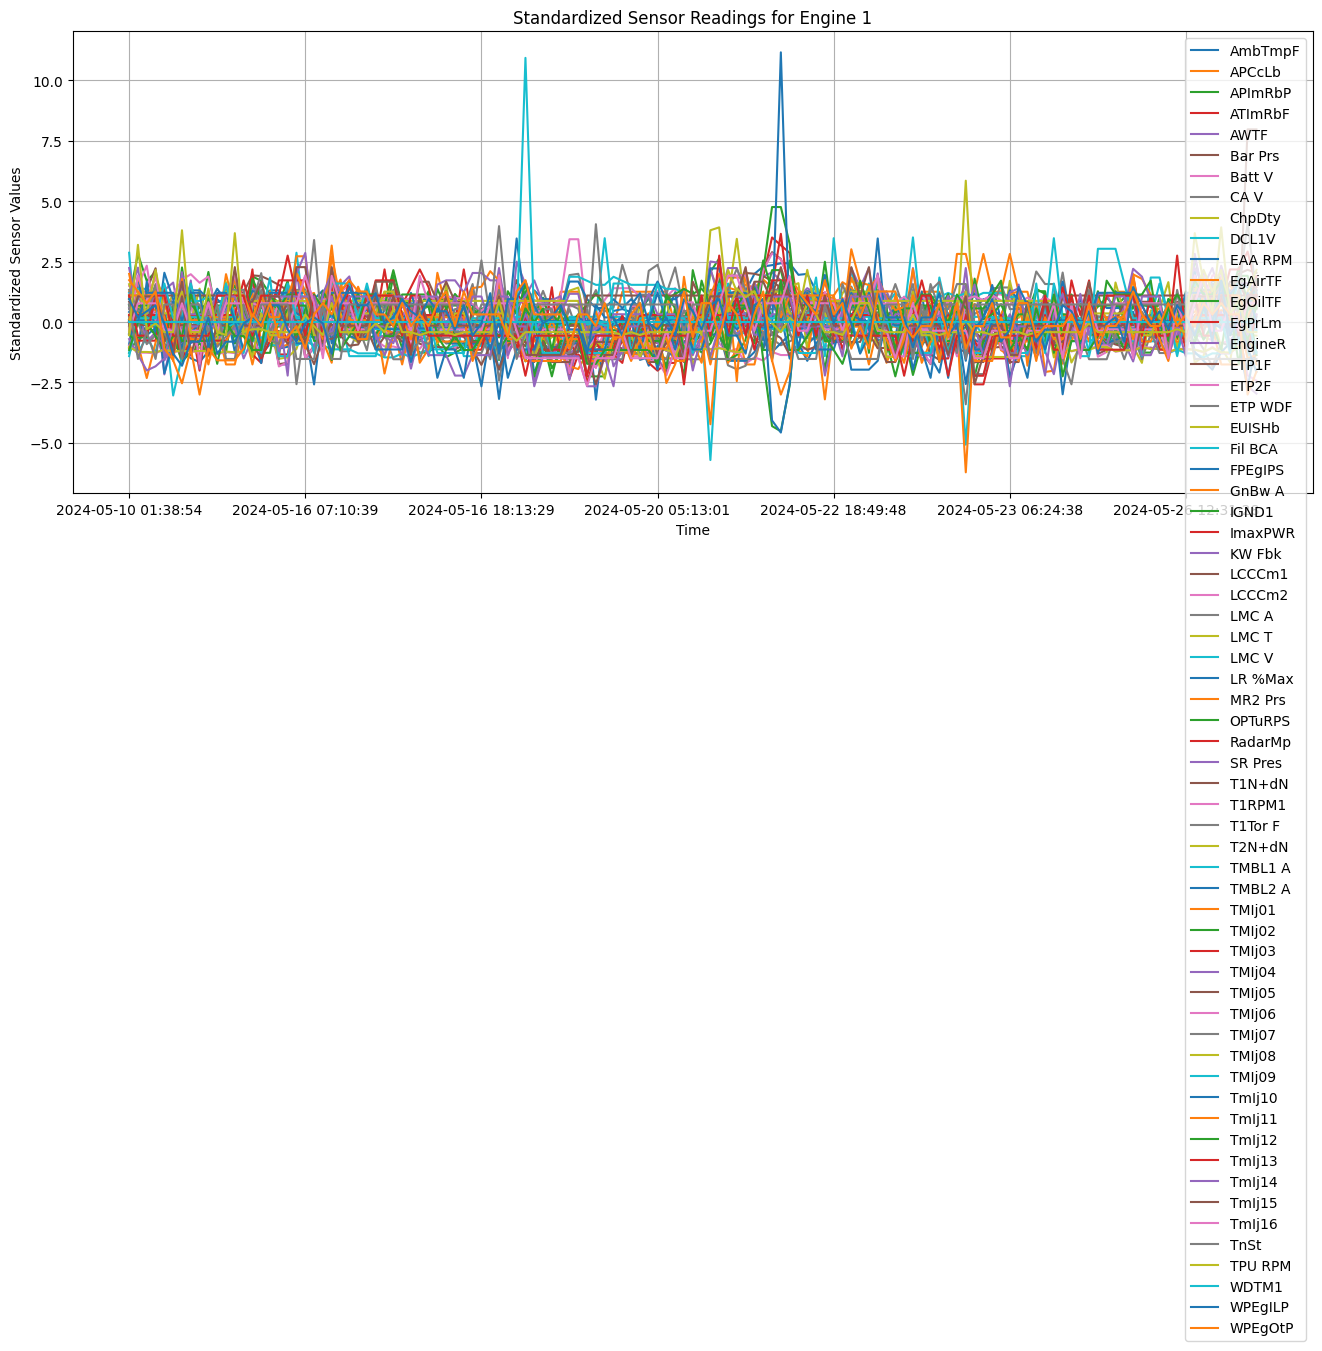

In [25]:
numeric_cols = df.select_dtypes(include='number').columns
zero_rows = df[numeric_cols].eq(0).all(axis=1)
zero_indices = df[zero_rows].index.to_list()
boundaries = [0] + zero_indices + [len(df)]

engine_idx = 0
start, end = boundaries[engine_idx], boundaries[engine_idx + 1]

engine_df = df.iloc[start:end].dropna(how='all').copy()

engine_df = engine_df.set_index('Time Stamp') if 'Time Stamp' in engine_df.columns else engine_df

sensor_cols = engine_df.select_dtypes(include='number').columns

scaler = StandardScaler()
engine_df_scaled = pd.DataFrame(scaler.fit_transform(engine_df[sensor_cols]),
                                 columns=sensor_cols, index=engine_df.index)

engine_df_scaled.plot(figsize=(16, 6), title=f"Standardized Sensor Readings for Engine {engine_idx + 1}")
plt.xlabel("Time")
plt.ylabel("Standardized Sensor Values")
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
numerical_cols = df.select_dtypes(include='number').columns
df_numeric = df[numerical_cols].copy()

def hampel_filter(series, window_size=5, n_sigmas=3):
    k = 1.4826
    new_series = series.copy()
    rolling_median = series.rolling(window=window_size, center=True).median()
    mad = k * (series.rolling(window=window_size, center=True)
                      .apply(lambda x: np.median(np.abs(x - np.median(x))), raw=True))
    difference = np.abs(series - rolling_median)
    outlier_idx = difference > (n_sigmas * mad)
    new_series[outlier_idx] = rolling_median[outlier_idx]
    return new_series


mask_real_data = ~(df['Asset Name'] == 0)

df_numeric_filtered = df_numeric[mask_real_data]

filtered_numeric_df_real = df_numeric_filtered.apply(lambda col: hampel_filter(col))

filtered_numeric_df = df_numeric.copy()
filtered_numeric_df.loc[mask_real_data] = filtered_numeric_df_real

df_filtered = pd.concat([filtered_numeric_df, df.drop(columns=numerical_cols)], axis=1)



In [27]:
def standardize_real_data(df, asset_col='Asset Name'):

    numerical_cols = df.select_dtypes(include='number').columns
    numeric_data = df[numerical_cols]

    mask_real_data = ~(df[asset_col] == 0)

    scaler = StandardScaler()
    scaled_array_real = scaler.fit_transform(numeric_data[mask_real_data])

    scaled_df_real = pd.DataFrame(scaled_array_real, columns=numerical_cols, index=numeric_data[mask_real_data].index)

    scaled_df = numeric_data.copy()
    scaled_df.loc[mask_real_data] = scaled_df_real

    df_standardized = pd.concat([scaled_df, df.drop(columns=numerical_cols)], axis=1)
    return df_standardized

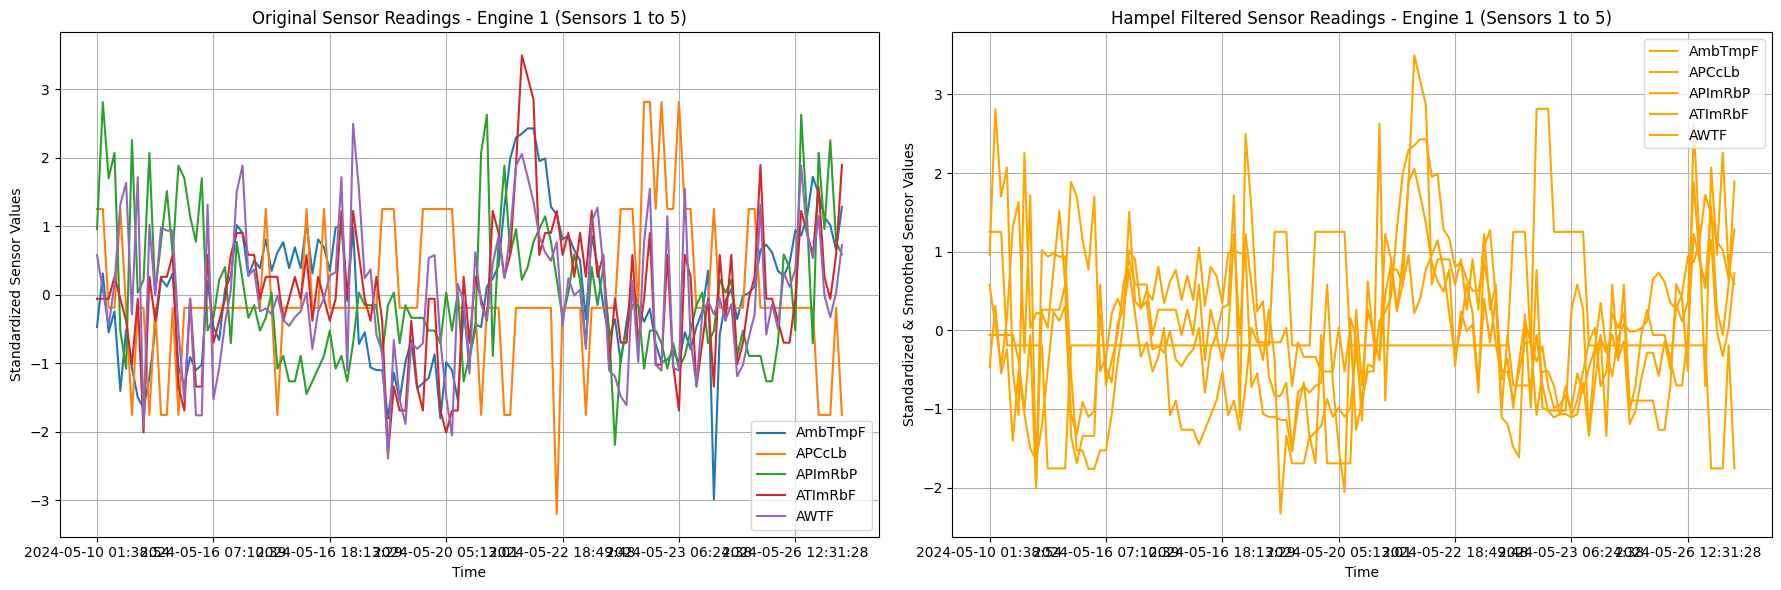

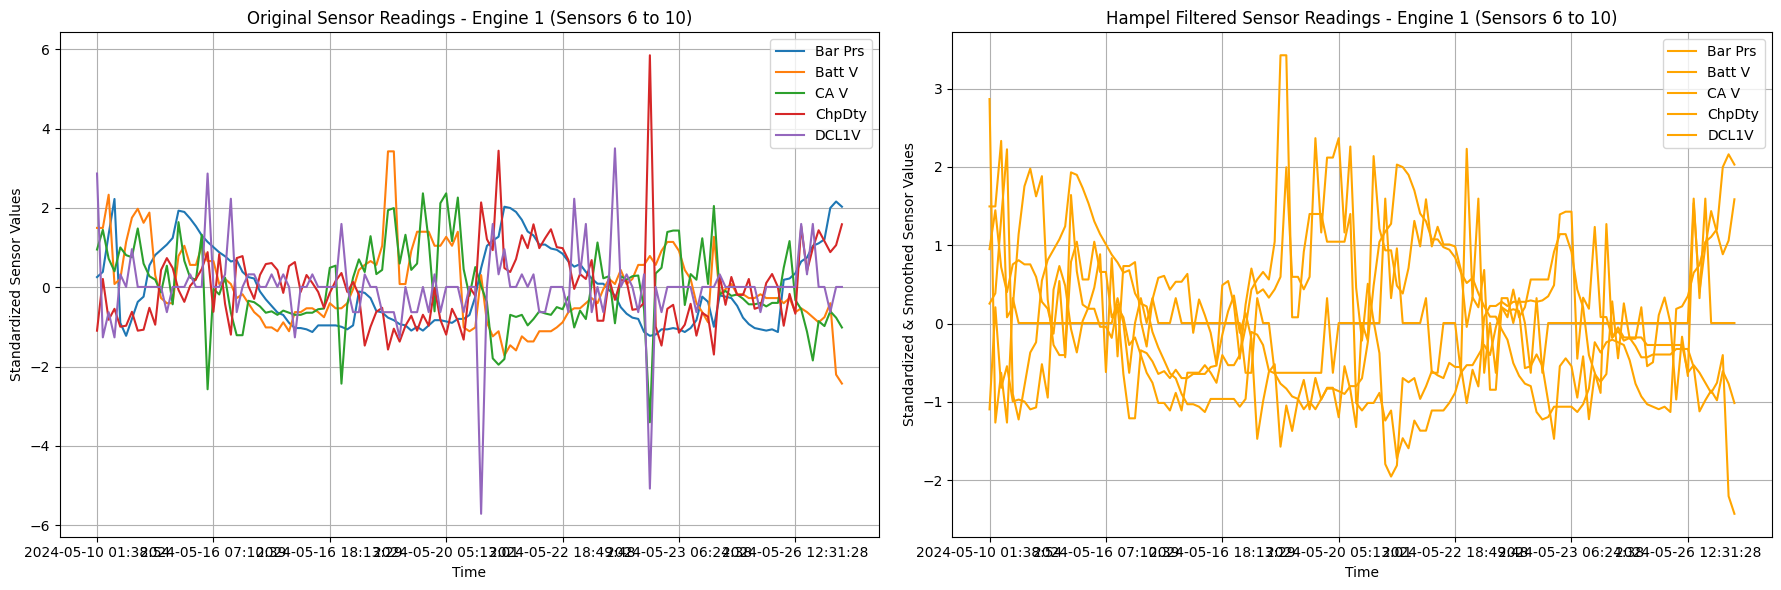

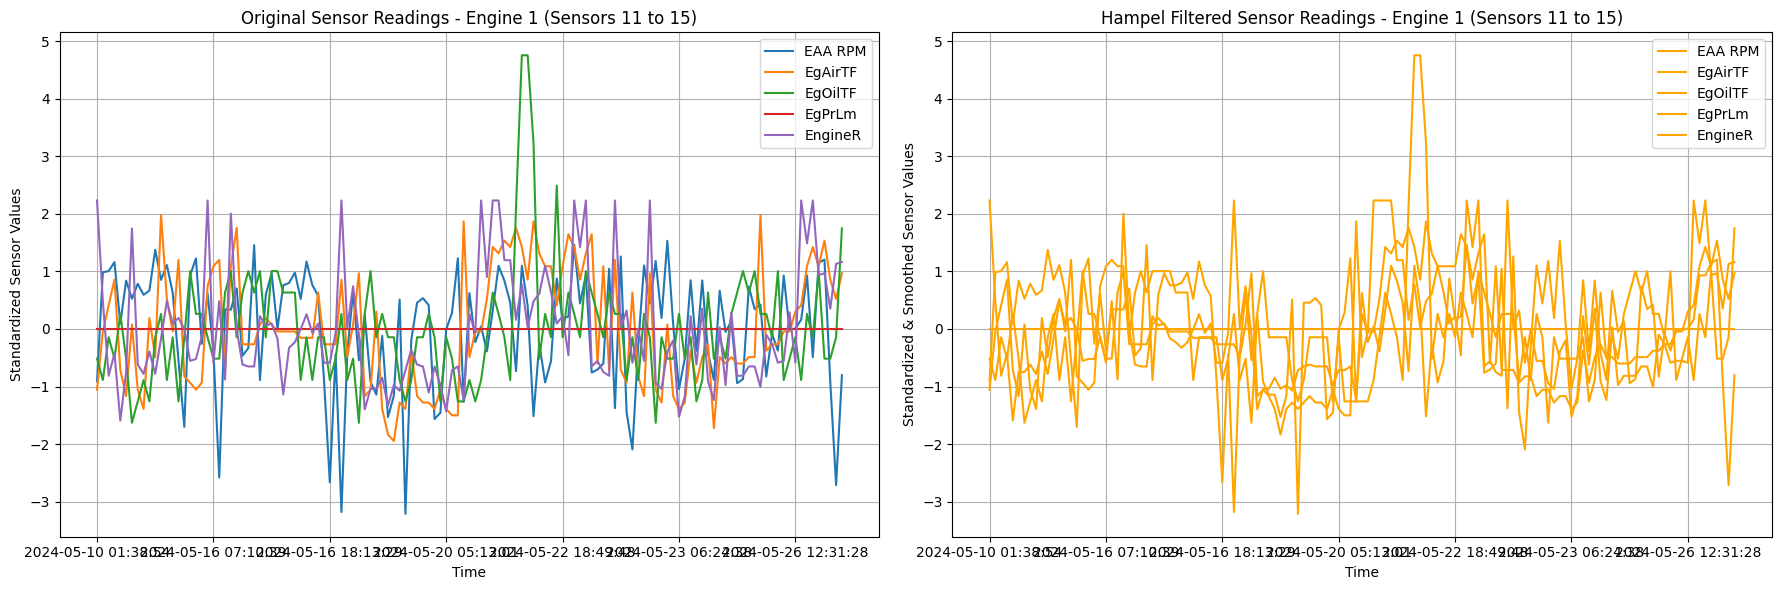

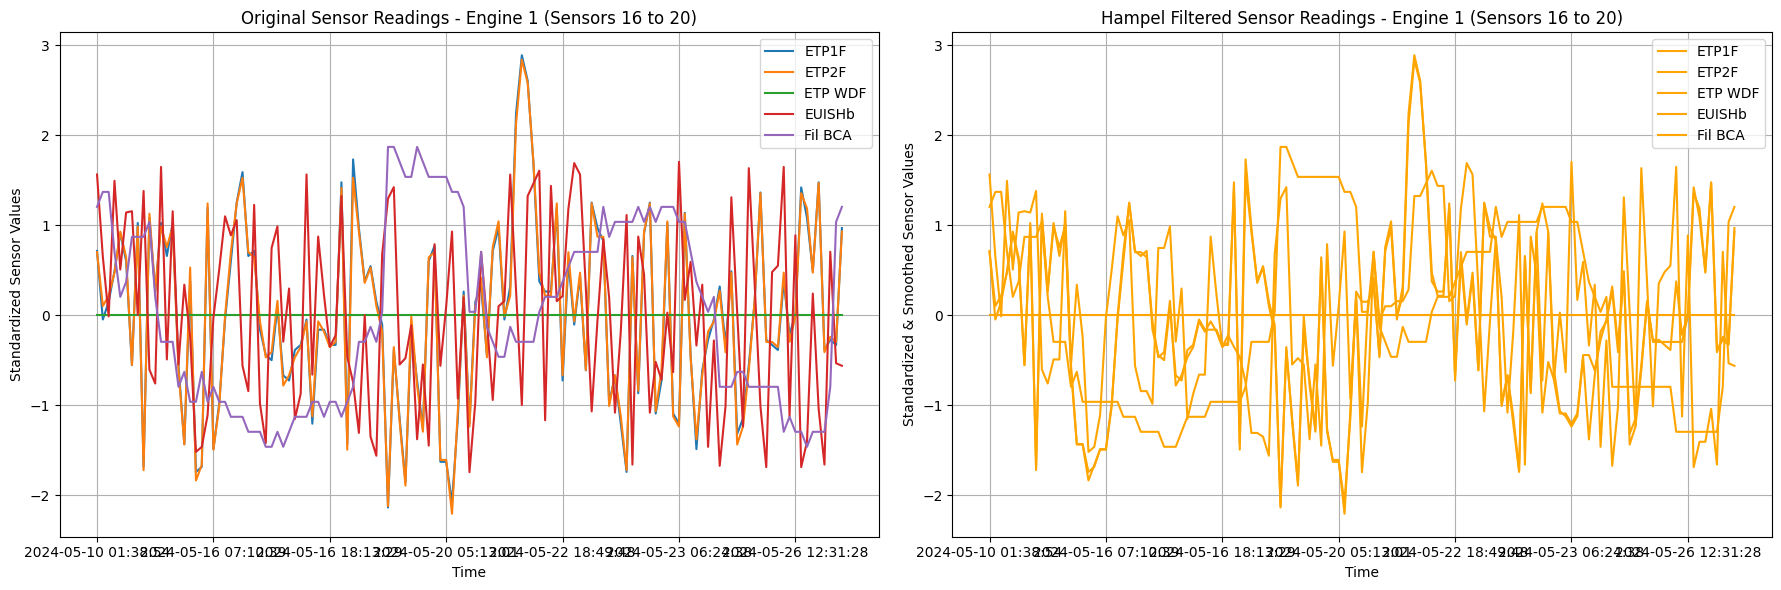

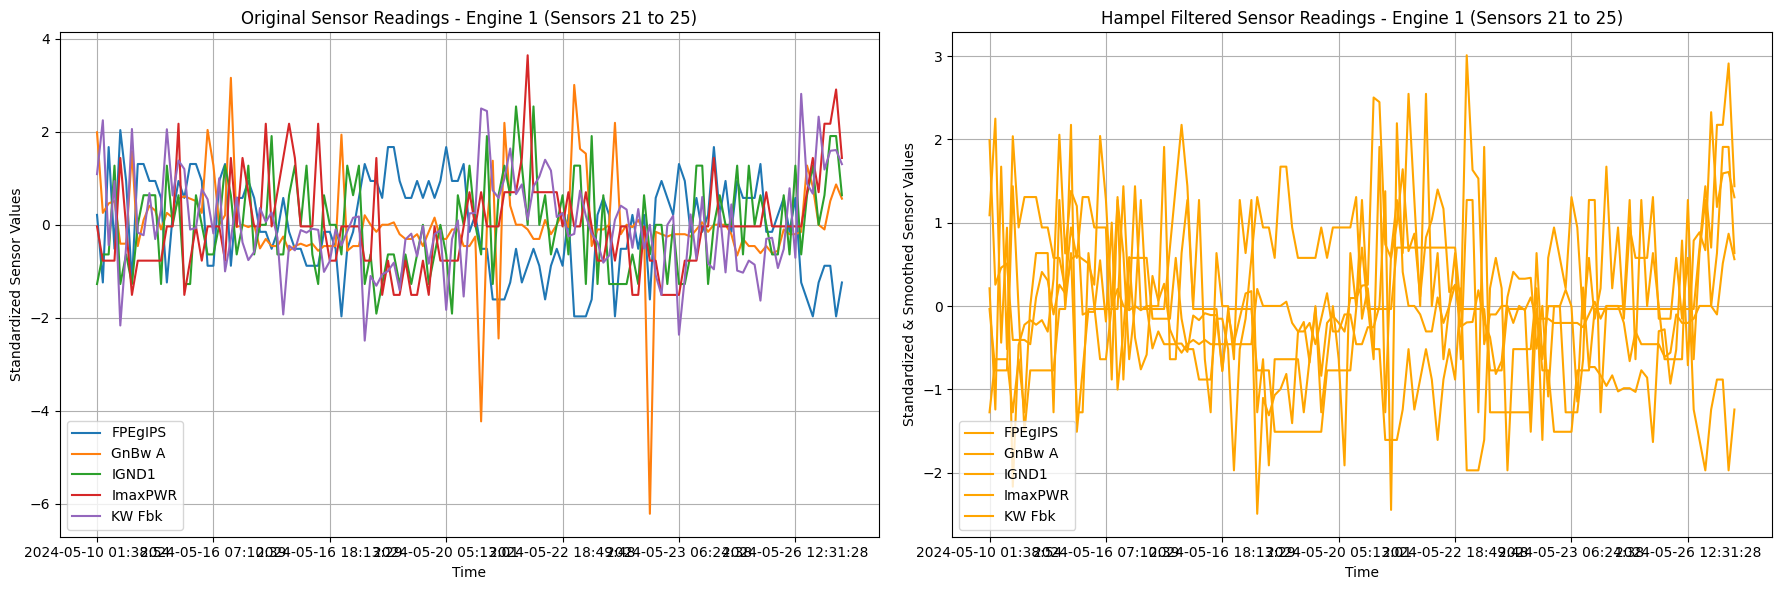

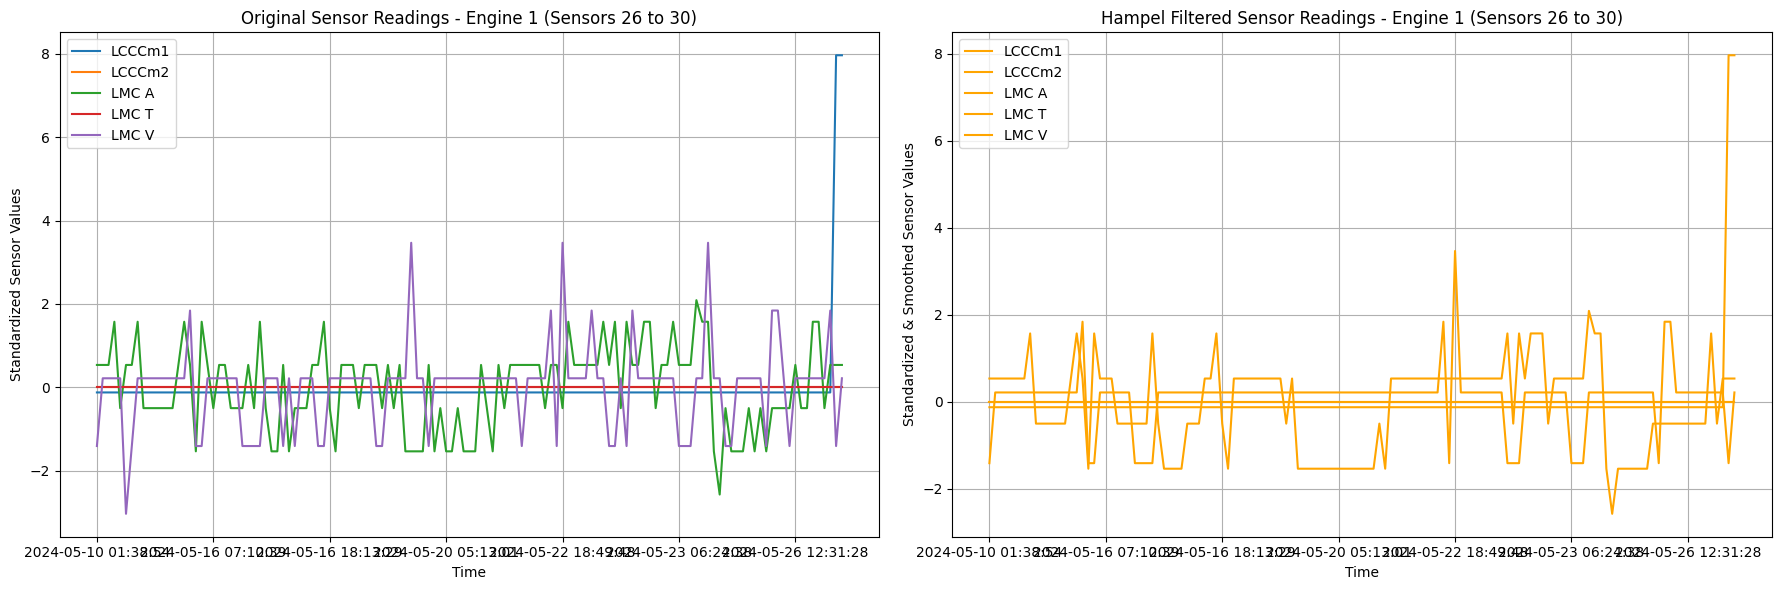

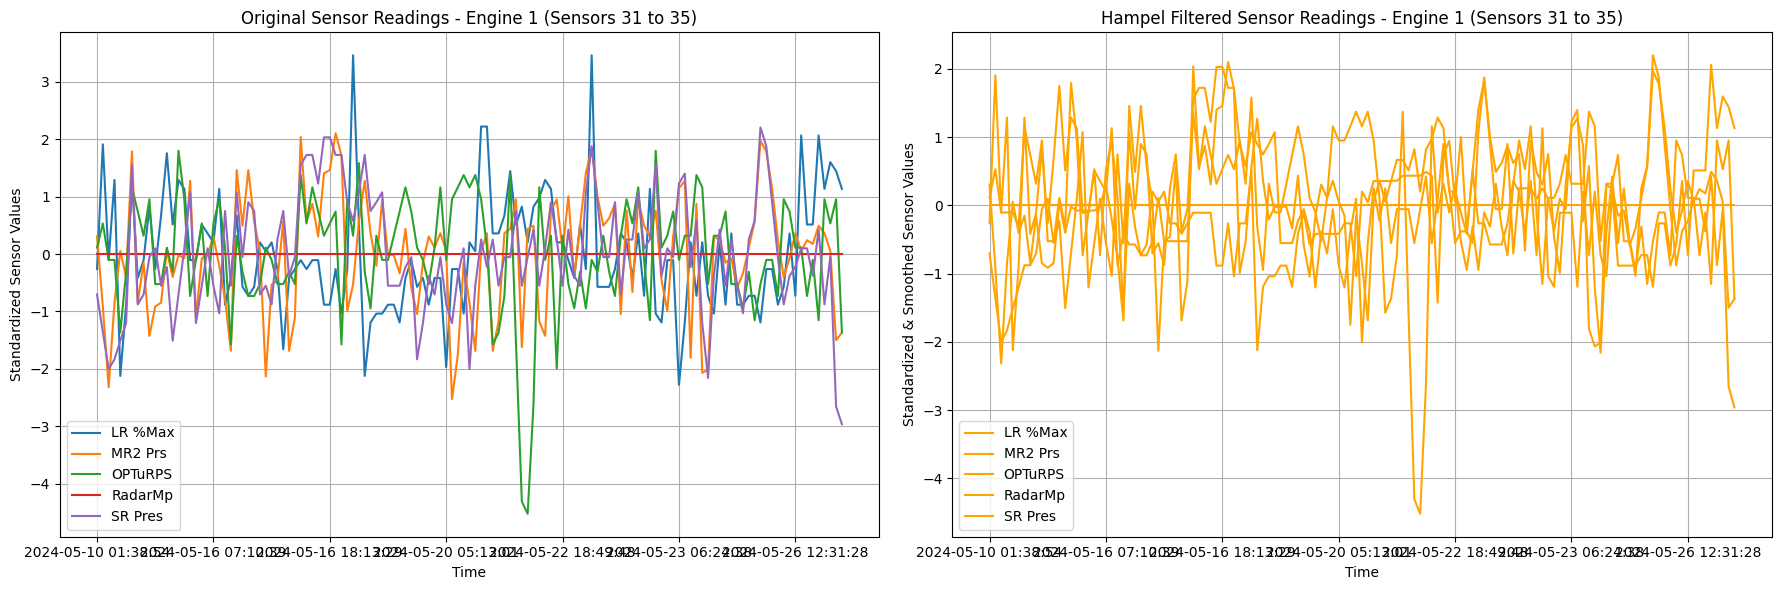

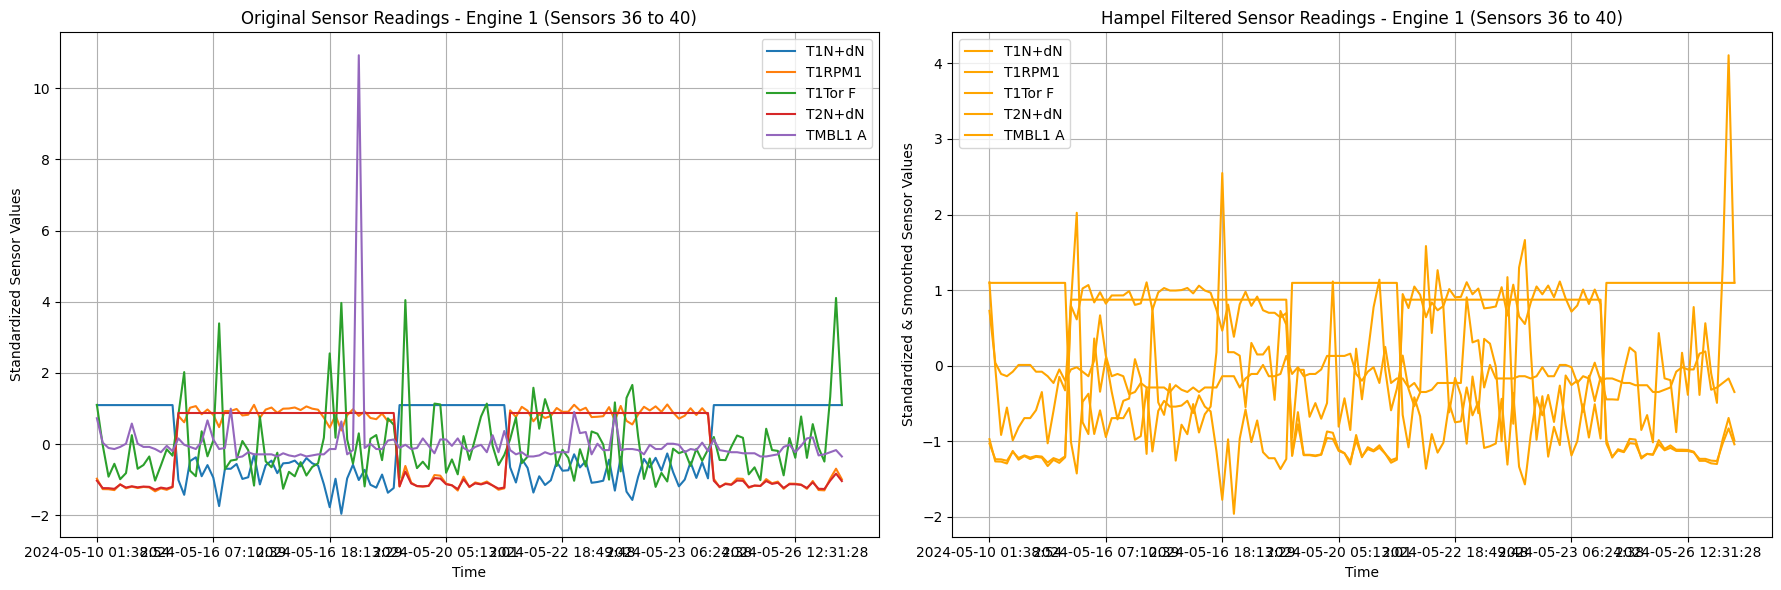

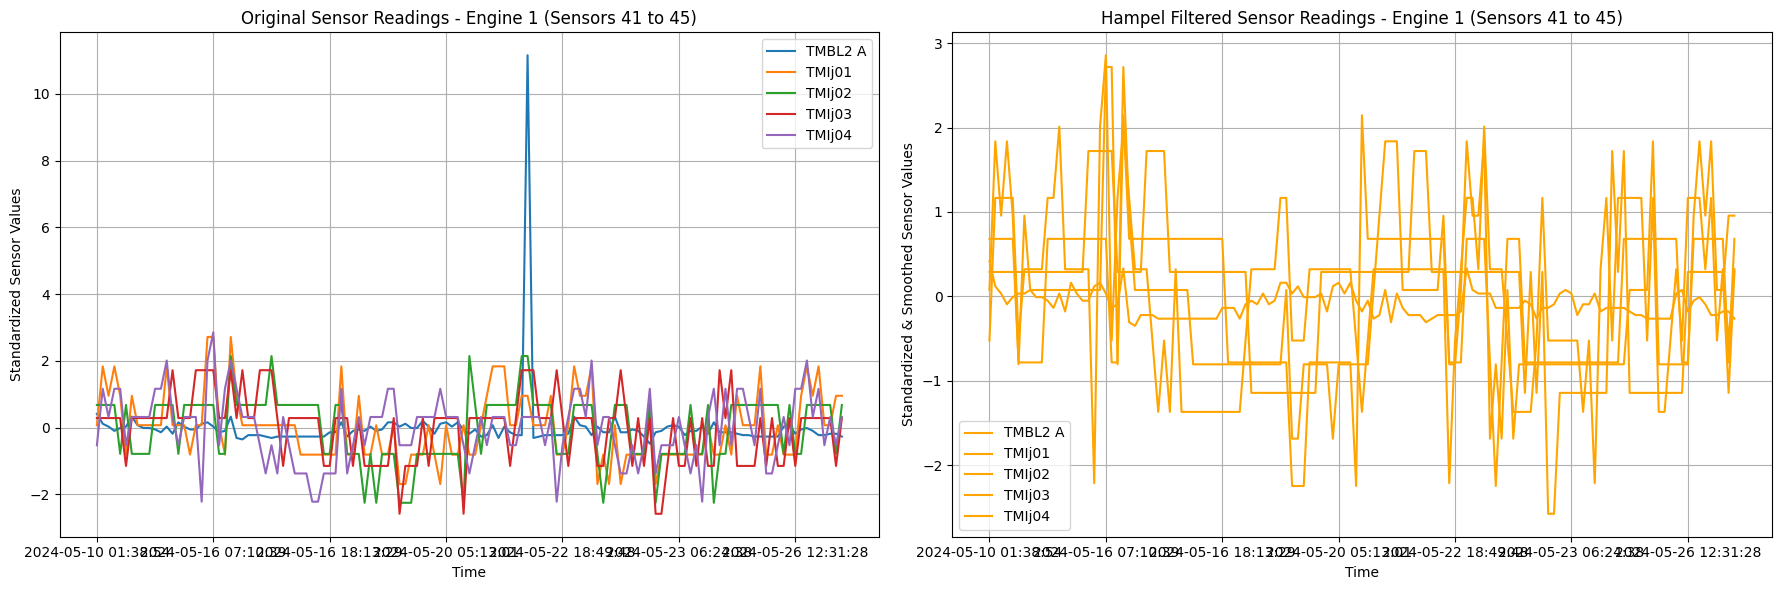

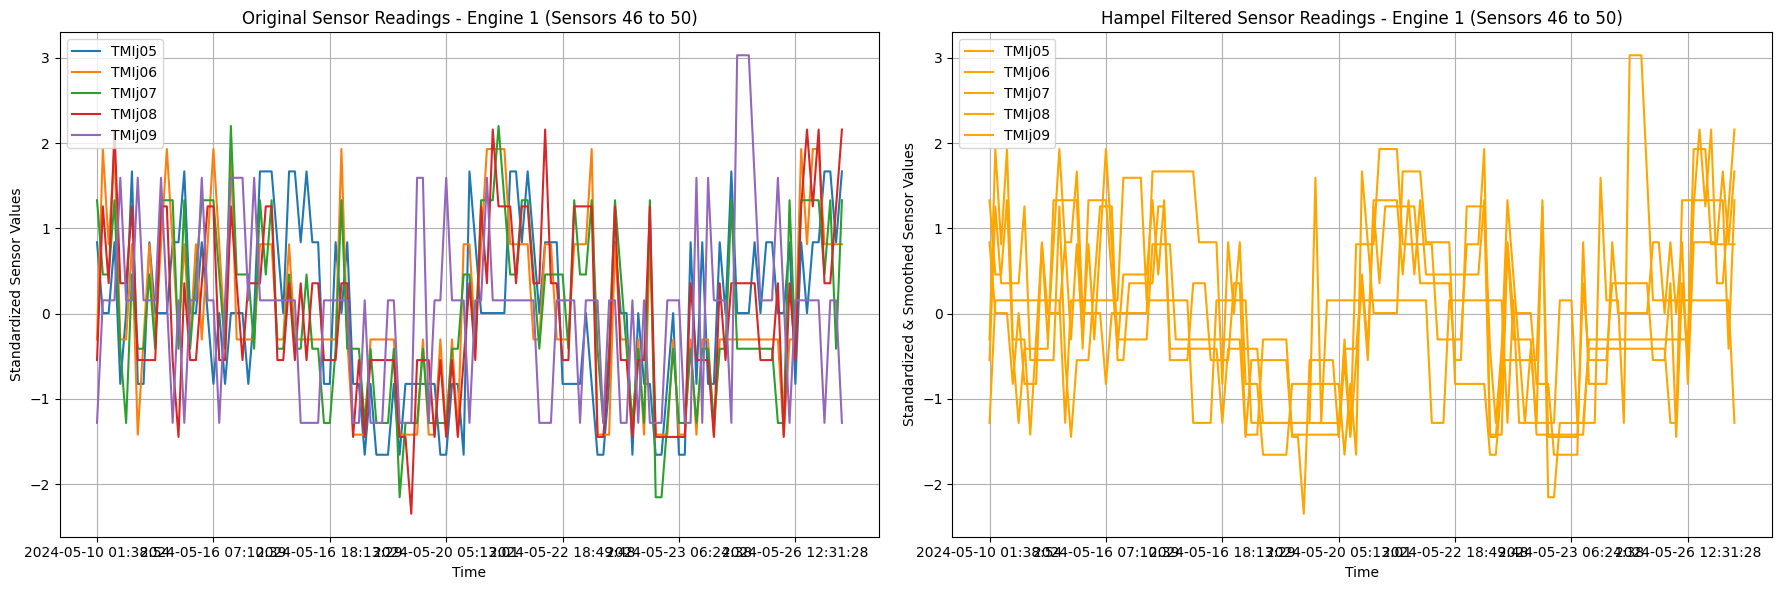

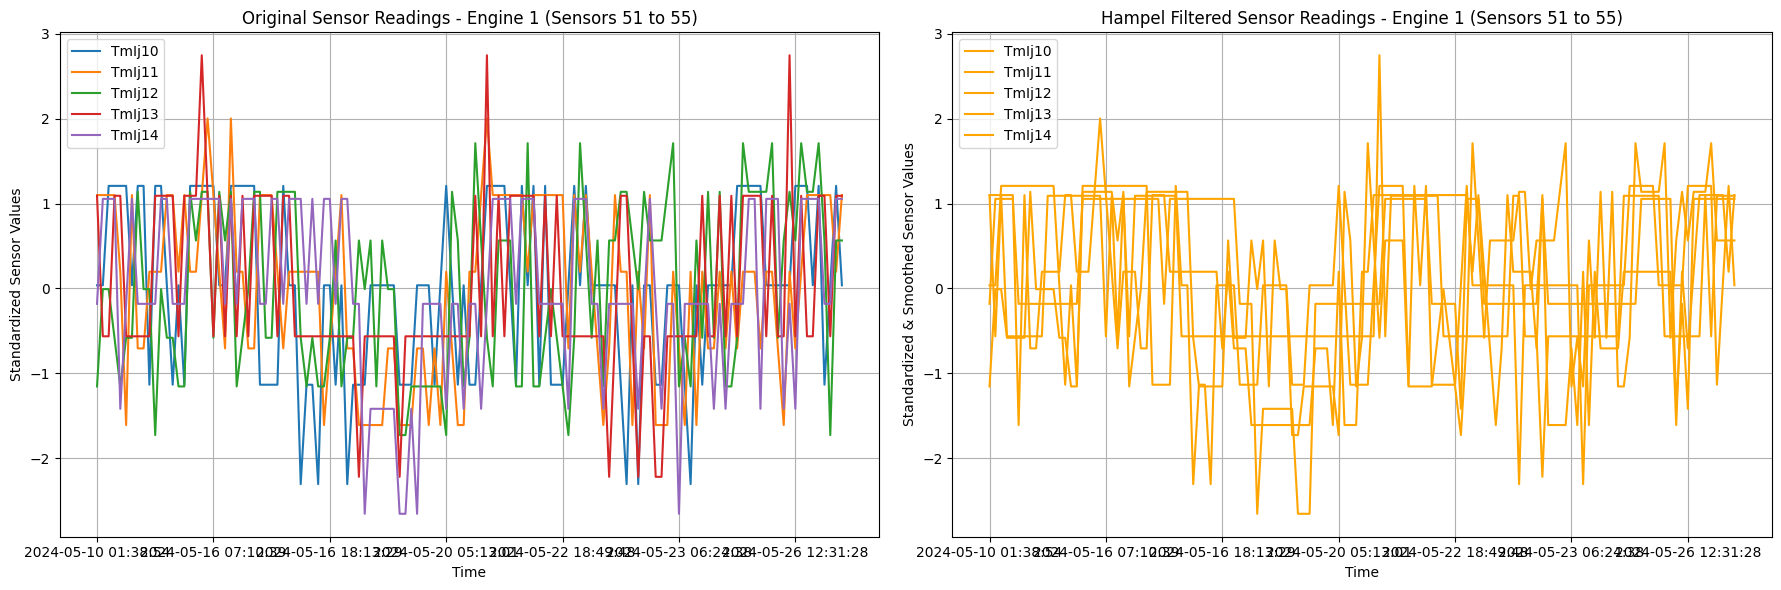

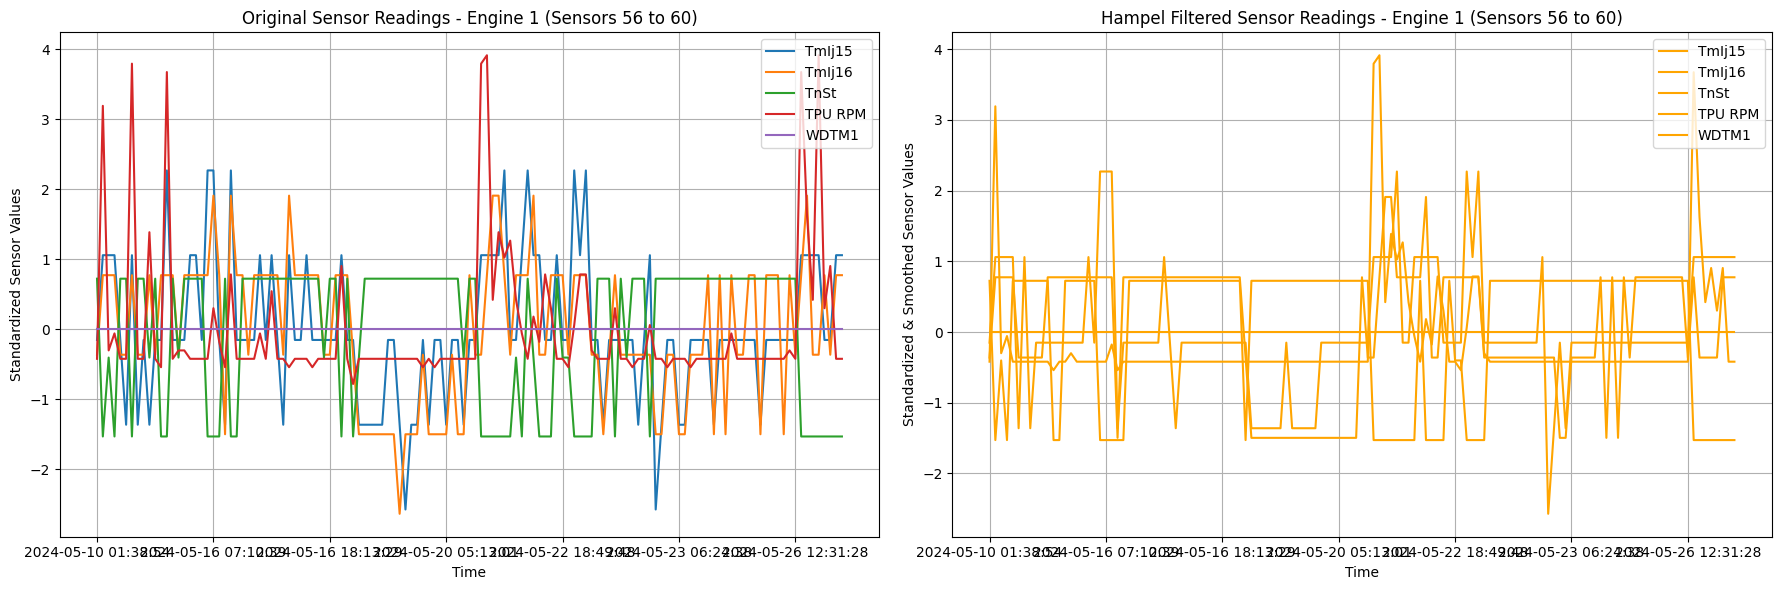

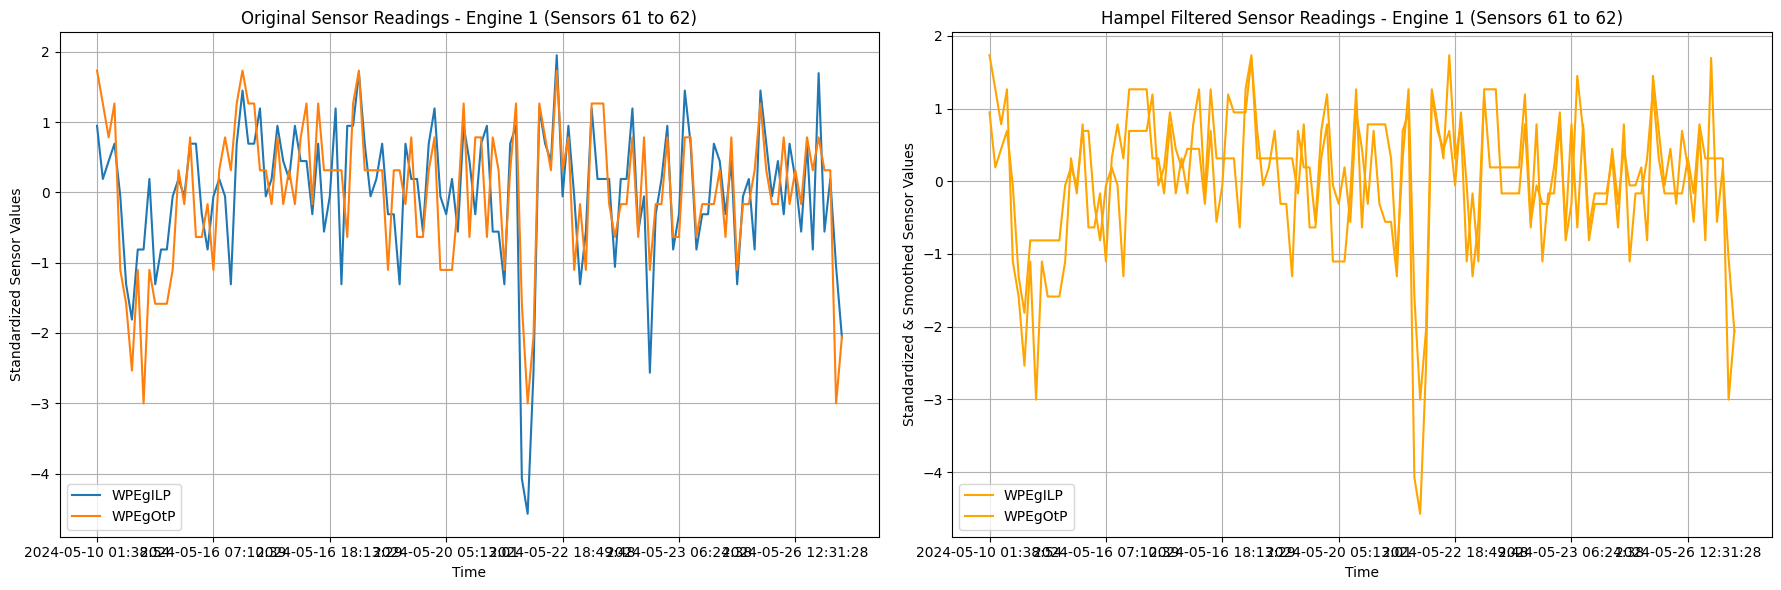

In [28]:
numeric_cols = df.select_dtypes(include='number').columns
zero_rows = df[numeric_cols].eq(0).all(axis=1)
zero_indices = df[zero_rows].index.to_list()
boundaries = [0] + zero_indices + [len(df)]

engine_idx = 0
start, end = boundaries[engine_idx], boundaries[engine_idx + 1]

engine_df = df.iloc[start:end].dropna(how='all').copy()

engine_df = engine_df.set_index('Time Stamp') if 'Time Stamp' in engine_df.columns else engine_df

sensor_cols = engine_df.select_dtypes(include='number').columns

scaler = StandardScaler()
engine_df_scaled = pd.DataFrame(scaler.fit_transform(engine_df[sensor_cols]),
                                 columns=sensor_cols, index=engine_df.index)



engine_df_smoothed = engine_df_scaled.apply(lambda col: hampel_filter(col))

step = 5
for i in range(0, len(sensor_cols), step):
    cols_slice = sensor_cols[i:i+step]
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    engine_df_scaled[cols_slice].plot(ax=axes[0], title=f"Original Sensor Readings - Engine {engine_idx + 1} (Sensors {i+1} to {i+len(cols_slice)})")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Standardized Sensor Values")
    axes[0].grid(True)

    engine_df_smoothed[cols_slice].plot(ax=axes[1], title=f"Hampel Filtered Sensor Readings - Engine {engine_idx + 1} (Sensors {i+1} to {i+len(cols_slice)})", color='orange')
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Standardized & Smoothed Sensor Values")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


In [29]:
df_standardized=standardize_real_data(df_filtered)
df_standardized['Time Stamp'] = pd.to_datetime(
    df_standardized['Time Stamp'],
    infer_datetime_format=True,
    errors='coerce'
)

print(df_standardized['Time Stamp'].head(10))
print("(NaT):", df_standardized['Time Stamp'].isna().sum())


0   2024-05-10 01:38:54
1   2024-05-10 02:06:25
2   2024-05-10 06:04:02
3   2024-05-10 07:50:03
4   2024-05-13 15:05:53
5   2024-05-13 22:39:27
6   2024-05-14 00:26:59
7   2024-05-14 02:06:00
8   2024-05-14 02:30:01
9   2024-05-14 05:38:03
Name: Time Stamp, dtype: datetime64[ns]
(NaT): 31


<ipython-input-27-dcb1194152a1>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 2.2553906   0.8565973   1.07179627 ... -0.86499444 -0.86499444
 -1.29539238]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaled_df.loc[mask_real_data] = scaled_df_real
<ipython-input-27-dcb1194152a1>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.04563645  0.59815489  0.61579845 ...  1.76262961  2.11550074
  0.28351147]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaled_df.loc[mask_real_data] = scaled_df_real
<ipython-input-27-dcb1194152a1>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.14998585 0.14998585 0.14998585 ... 0.14998585 0.14998585 0.14998585]' 

In [30]:
df_standardized.to_csv("df_standardized.csv", index=False)

In [31]:
df_standardized.head(10)

,AmbTmpF,APCcLb,APImRbP,ATImRbF,AWTF,Bar Prs,Batt V,CA V,ChpDty,DCL1V,...,TmIj15,TmIj16,TnSt,TPU RPM,WDTM1,WPEgILP,WPEgOtP,Time Stamp,Asset Name,failure_type
0,0.080447,-0.764641,-1.800280,-0.359353,0.326135,-0.940371,0.669579,1.113948,-2.126988,2.255391,...,-1.087537,-1.169912,2.937590,-1.849749,0.432396,0.848351,0.774408,2024-05-10 01:38:54,SAR 4005,no failure
1,0.534072,-0.764641,-1.265346,-0.359353,-0.037737,-0.839725,0.669579,1.533474,-1.043336,0.856597,...,-0.884107,-0.946040,-0.300412,-1.145500,0.432396,0.582323,0.645384,2024-05-10 02:06:25,SAR 4005,no failure
2,0.036191,-0.764641,-1.586182,-0.359353,-0.416770,-0.110722,0.952450,0.919168,-1.897754,1.071796,...,-0.884107,-0.946040,1.318589,-1.826379,0.432396,0.671851,0.512564,2024-05-10 06:04:02,SAR 4005,no failure
3,0.213215,-1.014973,-1.479444,-0.359353,0.022909,0.569319,0.190875,0.649472,-1.668520,0.856597,...,-0.884107,-0.946040,-0.300412,-1.779008,0.432396,0.758822,0.645384,2024-05-10 07:50:03,SAR 4005,no failure
4,-0.461689,-1.014973,-2.228166,-0.359353,0.856782,-1.824423,0.234393,0.949134,-2.043630,1.394595,...,-0.884107,-0.946040,2.937590,-1.849749,0.432396,0.495352,-0.007329,2024-05-13 15:05:53,SAR 4005,no failure
5,0.058319,-1.014973,-2.388584,-0.597160,1.084202,-2.074678,0.549903,0.994083,-2.022791,1.286995,...,-1.290967,-1.169912,2.937590,-1.849749,0.432396,0.055382,-0.140148,2024-05-13 22:39:27,SAR 4005,no failure
6,-0.262537,-1.014973,-1.425764,-1.072773,-0.295479,-1.748259,0.756616,0.949134,-2.043630,1.286995,...,-0.884107,-1.169912,2.937590,-1.849749,0.432396,-0.121118,-0.401992,2024-05-14 00:26:59,SAR 4005,no failure
7,-0.517009,-1.014973,-2.067747,-0.359353,1.144847,-1.419119,0.832774,0.949134,-2.126988,1.286995,...,-1.290967,-1.169912,2.937590,-1.849749,0.432396,0.229323,-0.007329,2024-05-14 02:06:00,SAR 4005,no failure
8,-0.605521,-1.014973,-2.014068,-1.807812,-1.478063,-1.318473,0.713097,0.814286,-2.106149,1.286995,...,-1.087537,-1.169912,2.937590,-1.849749,0.432396,0.229323,-0.531017,2024-05-14 02:30:01,SAR 4005,no failure
9,-0.351049,-1.014973,-2.014068,-0.121546,0.644523,-0.714597,0.800135,0.544591,-1.647680,1.286995,...,-1.087537,-1.169912,2.937590,-1.849749,0.432396,0.229323,-0.007329,2024-05-14 05:38:03,SAR 4005,no failure


## **Sliding Window Creation and Class Balancing**

After cleaning and transforming the time-series sensor data, we prepare the dataset for training by performing the following key steps:

### Step 1: Sliding Window Generation

To convert the time-series data into a supervised learning format, we apply a sliding window approach:
- Each window captures a sequence of sensor readings over a fixed time frame (`window_size=30`).
- A stride is used to control overlap between windows.
- Each window is labeled based on whether it contains failure events (`multi_class=True` for classification by failure type).

### Step 2: Oversampling to Balance Class Distribution

Due to the high imbalance in the raw dataset, we apply oversampling to ensure each class has the same number of training samples:
- Rare failure classes (e.g., `turbocharger`, `injector`) are duplicated.
- The `Resample` function is used to expand underrepresented classes to match the majority.

This results in a **fully balanced dataset** across all five classes:
- `0`: No failure  
- `1`: Turbocharger  
- `2`: Power Assembly  
- `3`: SRS_TRS  
- `4`: Injector  

Each class ends up with the same number of examples (e.g., **3941 samples per class**), as shown in the histogram and value counts.

### Benefit:
This step is essential to prevent model bias toward the majority class and ensure fair training across all failure categories.


In [32]:
def create_sliding_windows_with_oversampling(df, window_size=30, stride=1,
                                             target_col='failure_type', asset_col='Asset Name', multi_class=False):
    import numpy as np
    import pandas as pd
    from sklearn.utils import shuffle, resample

    sensor_cols = df.select_dtypes(include='number').columns.drop(target_col)

    X_windows, y_windows = [], []

    for asset in df[asset_col].unique():
        asset_df = df[df[asset_col] == asset]
        X_full = asset_df[sensor_cols].values
        y_full = asset_df[target_col].values

        for start in range(0, len(X_full) - window_size + 1, stride):
            end = start + window_size
            window_X = X_full[start:end]
            window_y = y_full[start:end]

            if window_X.shape[0] == window_size:
                if multi_class:
                    failures_in_window = window_y[window_y != 0]
                    if len(failures_in_window) > 0:
                        # أخذ أول نوع فشل يظهر داخل الـ window
                        label = failures_in_window[0]
                        X_windows.append(window_X)
                        y_windows.append(label)
                    # لو ما فيه failure ➔ نتجاهله (Stage 2 logic)
                else:
                    label = 1 if np.any(window_y == 1) else 0
                    X_windows.append(window_X)
                    y_windows.append(label)

    X_windows = np.array(X_windows)
    y_windows = np.array(y_windows)

    # Oversampling
    if multi_class:
        df_win = pd.DataFrame({'X': list(X_windows), 'y': y_windows})
        max_class = df_win['y'].value_counts().max()

        oversampled = []
        for label in df_win['y'].unique():
            subset = df_win[df_win['y'] == label]
            if len(subset) < max_class:
                subset_upsampled = resample(subset, replace=True, n_samples=max_class, random_state=42)
            else:
                subset_upsampled = subset
            oversampled.append(subset_upsampled)

        df_balanced = pd.concat(oversampled)
        X_balanced = np.stack(df_balanced['X'].values)
        y_balanced = df_balanced['y'].values

    else:
        X_failure = X_windows[y_windows == 1]
        y_failure = y_windows[y_windows == 1]
        X_normal = X_windows[y_windows == 0]
        y_normal = y_windows[y_windows == 0]

        n_samples_needed = len(X_normal) - len(X_failure)
        repeats = (n_samples_needed // len(X_failure)) + 1

        X_failure_oversampled = np.repeat(X_failure, repeats, axis=0)[:n_samples_needed]
        y_failure_oversampled = np.repeat(y_failure, repeats, axis=0)[:n_samples_needed]

        X_balanced = np.concatenate([X_normal, X_failure, X_failure_oversampled], axis=0)
        y_balanced = np.concatenate([y_normal, y_failure, y_failure_oversampled], axis=0)

    return shuffle(X_balanced, y_balanced, random_state=42)


In [116]:
def plot_roc_and_confusion(y_true, y_pred_probs, threshold=0.5, class_names=None):
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc, confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    if len(y_pred_probs.shape) == 1 or y_pred_probs.shape[1] == 1:
        n_classes = 2
    else:
        n_classes = y_pred_probs.shape[1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ===== ROC curve =====
    if n_classes == 2:
        # Binary case
        if len(y_pred_probs.shape) > 1:
            y_pred_probs = y_pred_probs.ravel()  # flatten if shape (n_samples, 1)
        fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
        roc_auc = auc(fpr, tpr)

        axes[0].plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", linewidth=2)
        axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")
    else:
        # Multi-class case
        y_true_bin = label_binarize(y_true, classes=range(n_classes))
        fpr = dict()
        tpr = dict()
        roc_auc = dict()

        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            axes[0].plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

        axes[0].plot([0, 1], [0, 1], 'k--', label='Random')

    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve")
    axes[0].legend()
    axes[0].grid(True)

    # ===== Confusion Matrix =====
    if n_classes == 2:
        y_pred_classes = (y_pred_probs > threshold).astype(int)
        cm = confusion_matrix(y_true, y_pred_classes)
    else:
        y_pred_classes = np.argmax(y_pred_probs, axis=1)
        cm = confusion_matrix(y_true, y_pred_classes)

    if class_names is None:
        class_names = [f"Class {i}" for i in range(cm.shape[0])]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title('Confusion Matrix')

    plt.tight_layout()
    plt.show()


<ipython-input-27-dcb1194152a1>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 2.2553906   0.8565973   1.07179627 ... -0.86499444 -0.86499444
 -1.29539238]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaled_df.loc[mask_real_data] = scaled_df_real
<ipython-input-27-dcb1194152a1>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.04563645  0.59815489  0.61579845 ...  1.76262961  2.11550074
  0.28351147]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaled_df.loc[mask_real_data] = scaled_df_real
<ipython-input-27-dcb1194152a1>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.14998585 0.14998585 0.14998585 ... 0.14998585 0.14998585 0.14998585]' 

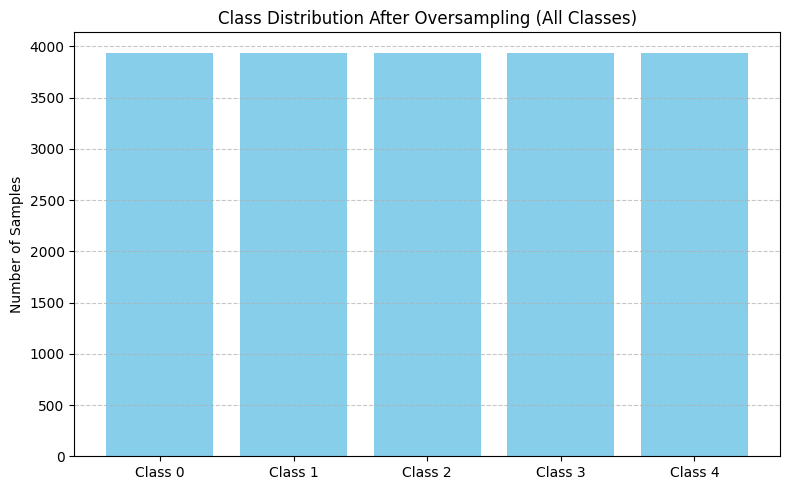

In [34]:
df_balance= standardize_real_data(df_filtered)
failure_classes = {
    'no failure': 0,
    0: 0,
    'turbocharger': 1,
    'power_assembly': 2,
    'SRS_TRS': 3,
    'injector': 4
}

df_balance['failure_type'] = df_balance['failure_type'].map(failure_classes).fillna(0).astype(int)

X_balanced, y_balanced = create_sliding_windows_with_oversampling(df_balance, multi_class=True)

class_counts = np.bincount(y_balanced)


class_labels = [f"Class {i}" for i in range(len(class_counts))]


plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_counts, color='skyblue')
plt.title("Class Distribution After Oversampling (All Classes)")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [35]:
print(pd.Series(y_balanced).value_counts())


3    3941
0    3941
2    3941
1    3941
4    3941
Name: count, dtype: int64


In [36]:
df_binary=df_standardized.copy()
df_binary['failure_type'] = df_binary['failure_type'].apply(
    lambda x: 0 if (x == 'no failure' or x == 0) else 1
)

# **Stage1 : Binary Classification**

In this stage, we aim to predict whether an engine instance will fail (`1`) or not (`0`) using time-series sensor data. We test multiple modeling approaches under two main setups:


We divide our experiments into two main categories based on preprocessing techniques:

### A. Without Oversampling (Baseline Models)
These models are trained on the original imbalanced dataset without applying any windowing or class balancing. This helps assess how well each model performs under real-world class distribution.

- **Model 1**: LSTM  
- **Model 2**: GRU  
- **Model 3**: XGBoost  
- **Model 4**: Random Forest  

### B. With Sliding Windows and Oversampling (Enhanced Models)
In these experiments, we improve performance by:
- Segmenting the time-series data into fixed-length **sliding windows**
- Applying **oversampling** to balance class distributions across training data

These enhancements aim to make the models more sensitive to rare failure events.

- **Model 1**: LSTM + Sliding Window + Oversampling  
- **Model 2**: GRU + Sliding Window + Oversampling  
- **Model 3**: XGBoost + Oversampling  
- **Model 4**: Random Forest + Oversampling  

---

## Evaluation Metrics

Each model is evaluated using:
- **Accuracy**
- **Precision / Recall**
- **F1-Score**
- **Confusion Matrix**
- **ROC Curve & AUC Score**

This multi-metric approach ensures balanced evaluation across both majority and minority classes.


## A.Models Without Oversampling (Baseline Models)


### **A.1 LSTM**
### Objective:
Classify whether an instance indicates **failure** or **no failure** based on raw sensor readings, without windowing or data balancing techniques.

**Model Architecture**
   - An LSTM layer with 64 units to capture temporal dependencies.
   - A Dense layer for binary output using the sigmoid activation function.
   - Binary cross-entropy loss and Adam optimizer are used.

**Training**
   - Early stopping is applied to avoid overfitting.
   - Model is trained for a maximum of 20 epochs with a batch size of 32.

In [52]:
feature_cols = df_binary.columns.drop(['failure_type', 'Time Stamp','Asset Name'], errors='ignore')

X = df_binary[feature_cols]
y = df_binary['failure_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

X_train = np.expand_dims(X_train.values, axis=1)
X_test = np.expand_dims(X_test.values, axis=1)

model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])



model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop])

eval_result = model.evaluate(X_test, y_test)
print(f"\n Evaluation: Loss={eval_result[0]:.4f}, Accuracy={eval_result[1]:.4f}, Precision={eval_result[2]:.4f}, Recall={eval_result[3]:.4f}")


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


122/122 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8907 - loss: 0.5360 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_accuracy: 0.9918 - val_loss: 0.0475 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 2/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9920 - loss: 0.0505 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_accuracy: 0.9918 - val_loss: 0.0515 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 3/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9939 - loss: 0.0358 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_accuracy: 0.9918 - val_loss: 0.0519 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 4/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9942 - loss: 0.0399 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_accuracy: 0.9918 - val_loss: 0.0529 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 5/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9928 - 

In [53]:
# Predict probabilities
y_pred_probs = model.predict(X_test).ravel()
# Convert probabilities to class labels
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# Compute precision, recall, f1
precision = precision_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)

print(f"Precision (sklearn): {precision:.4f}")
print(f"Recall (sklearn): {recall:.4f}")
print(f"F1 Score (sklearn): {f1:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Precision (sklearn): 0.0000
Recall (sklearn): 0.0000
F1 Score (sklearn): 0.0000


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


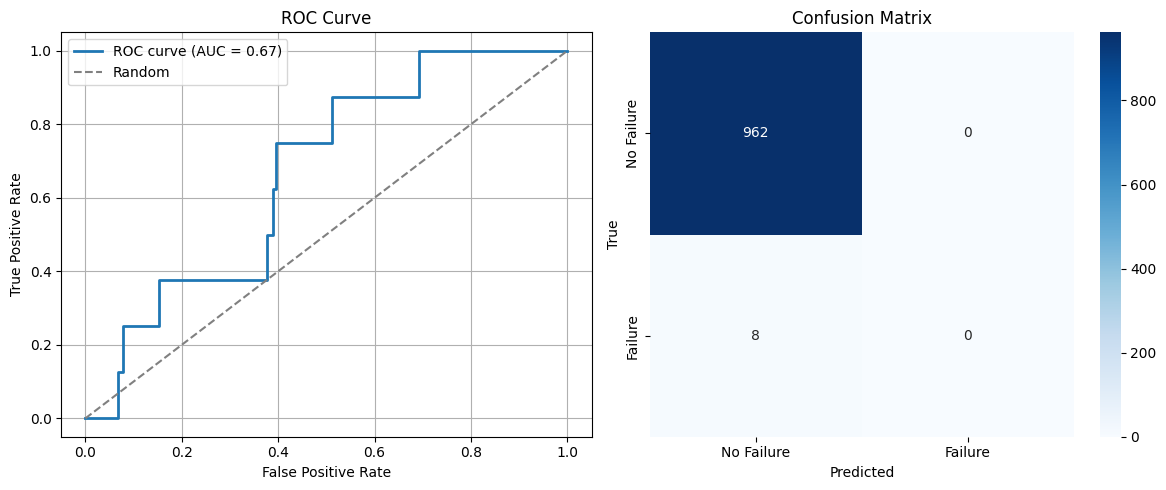

In [39]:
# Call the function
plot_roc_and_confusion(y_test, y_pred_probs)

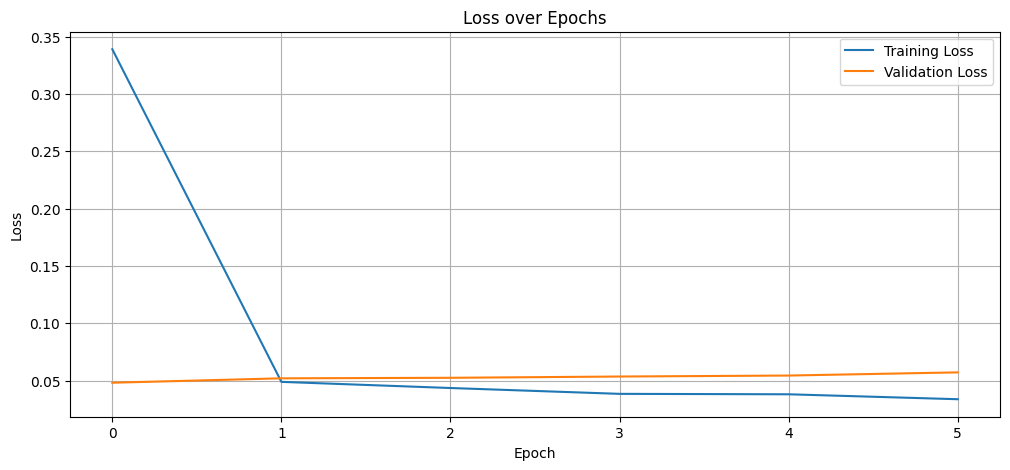

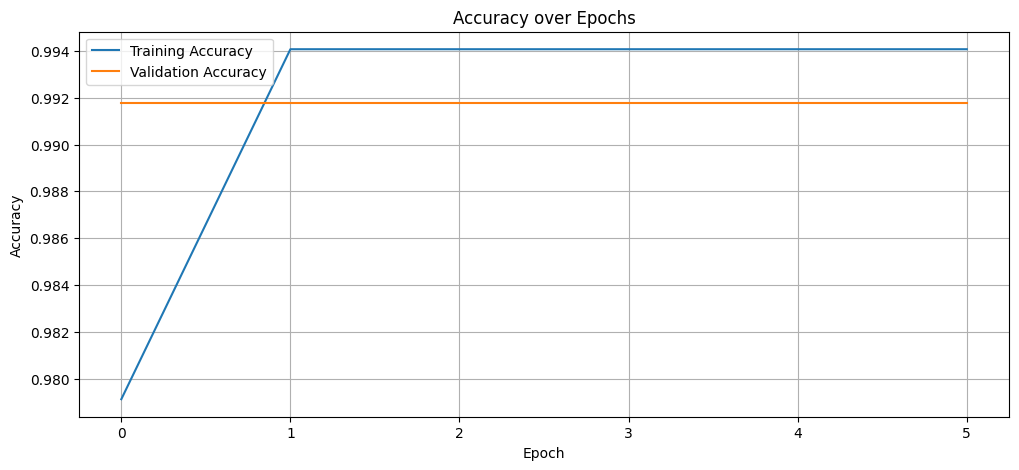

In [40]:

# --- Loss ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### **A.2 GRU**

**Model Architecture**
   - GRU layer with 64 units.
   - Dense layer with sigmoid activation for binary classification.
   - Binary cross-entropy loss and Adam optimizer.

**Training and Evaluation**
   - Early stopping applied.
   - Model evaluated using accuracy, precision, recall, and confusion matrix.
   - Performance is visualized over training epochs (loss and accuracy plots).



In [41]:
feature_cols = df_binary.columns.drop(['failure_type', 'Time Stamp','Asset Name'], errors='ignore')

X = df_binary[feature_cols]
y = df_binary['failure_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

X_train = np.expand_dims(X_train.values, axis=1)
X_test = np.expand_dims(X_test.values, axis=1)

GRU_model = Sequential([
    GRU(64, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    GRU(32, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

GRU_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = GRU_model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop])

eval_result = GRU_model.evaluate(X_test, y_test)
print(f"\n Evaluation: Loss={eval_result[0]:.4f}, Accuracy={eval_result[1]:.4f}, Precision={eval_result[2]:.4f}, Recall={eval_result[3]:.4f}")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


122/122 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.7958 - loss: 0.4828 - precision_1: 0.0036 - recall_1: 0.1039 - val_accuracy: 0.9918 - val_loss: 0.0478 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 2/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9947 - loss: 0.0493 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9918 - val_loss: 0.0523 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 3/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9943 - loss: 0.0458 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9918 - val_loss: 0.0560 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 4/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9920 - loss: 0.0542 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9918 - val_loss: 0.0584 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 5/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9957 - loss: 0.

In [54]:
# Predict probabilities
y_pred_probs = GRU_model.predict(X_test).ravel()
# Convert probabilities to class labels
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# Compute precision, recall, f1
precision = precision_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)

print(f"Precision (sklearn): {precision:.4f}")
print(f"Recall (sklearn): {recall:.4f}")
print(f"F1 Score (sklearn): {f1:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Precision (sklearn): 0.0000
Recall (sklearn): 0.0000
F1 Score (sklearn): 0.0000


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


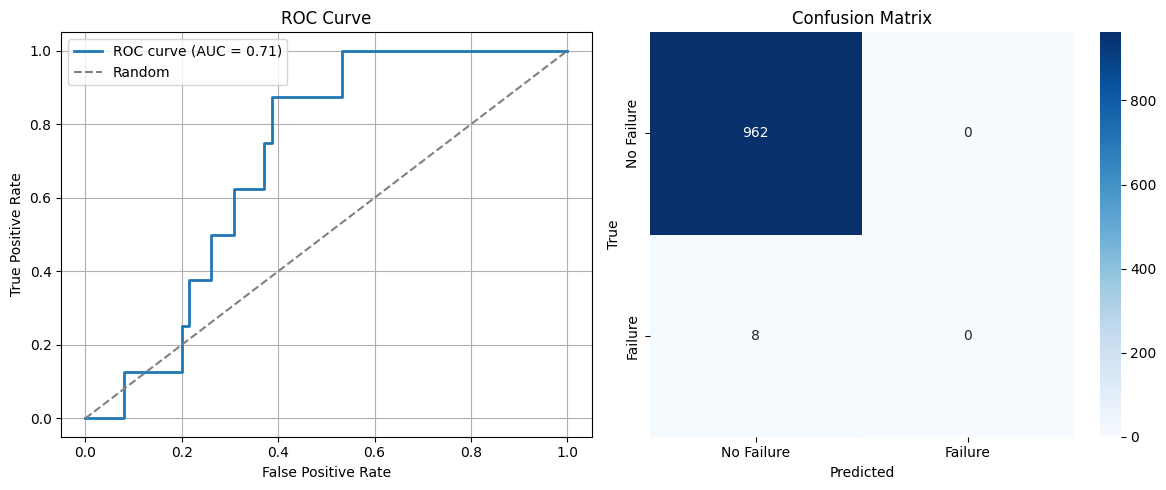

In [42]:
# Call the function
plot_roc_and_confusion(y_test, y_pred_probs)

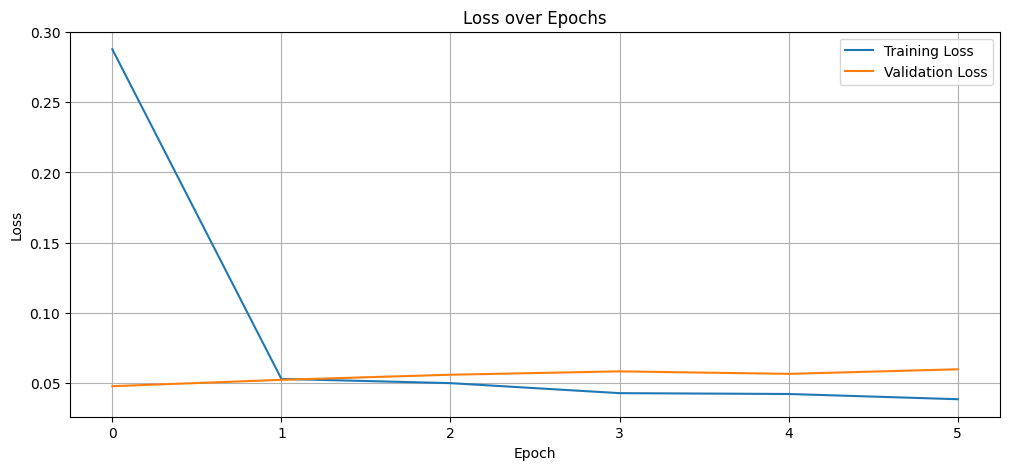

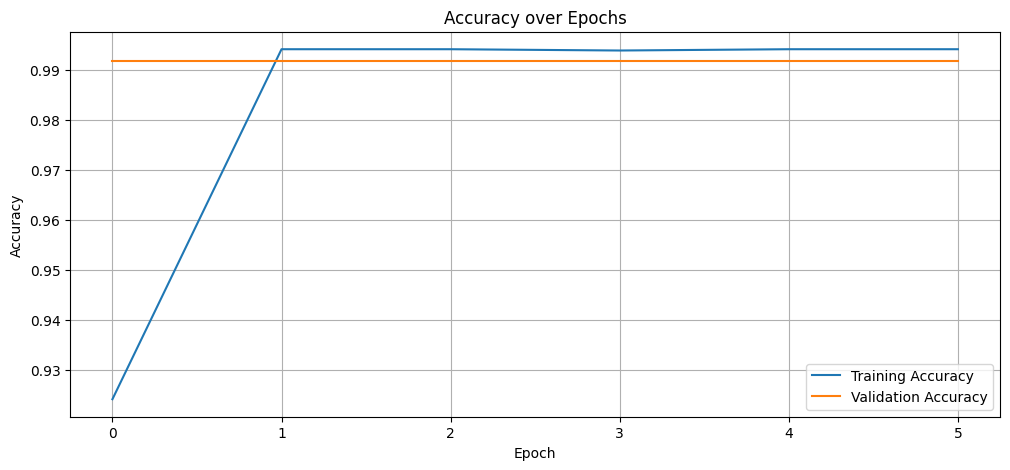

In [43]:
# --- Loss ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


###**A.3 XGBoost**

This model uses an XGBoost classifier on the original (imbalanced) dataset without oversampling or sequence-based slicing.

- XGBoost is configured with `scale_pos_weight` to slightly compensate for imbalance.



In [65]:
feature_cols = df_binary.columns.drop(['failure_type','Asset Name', 'Time Stamp'], errors='ignore')
X = df_binary[feature_cols]
y = df_binary['failure_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_Xg = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

model_Xg.fit(X_train, y_train)



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:00:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [66]:
y_pred = model_Xg.predict(X_test)
print("\n Classification Report:")
print(classification_report(y_test, y_pred))



 Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       962
           1       0.00      0.00      0.00         8

    accuracy                           0.99       970
   macro avg       0.50      0.50      0.50       970
weighted avg       0.98      0.99      0.99       970



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


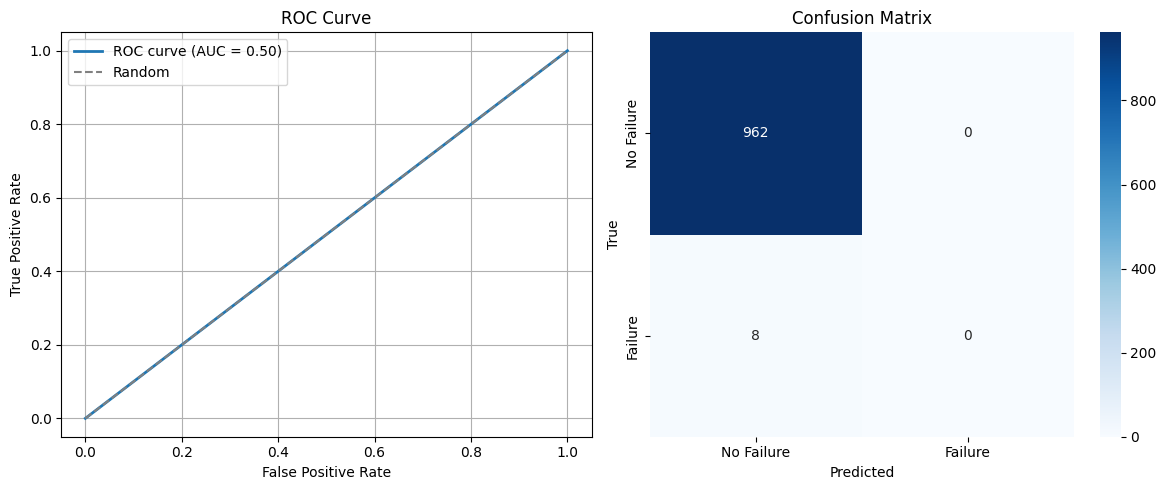

In [67]:
# Predict probabilities
y_pred_probs = model_Xg.predict(X_test).ravel()

# Call the function
plot_roc_and_confusion(y_test, y_pred_probs)

### **A.4 RF**

This model applies a Random Forest Classifier to the raw (imbalanced) dataset to perform binary classification.

- Training performed using an 80/20 split.





In [68]:
feature_cols = df_binary.columns.drop(['failure_type','Asset Name', 'Time Stamp'], errors='ignore')
X = df_binary[feature_cols]
y = df_binary['failure_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [69]:
y_pred = model.predict(X_test)
print("\n Classification Report:")
print(classification_report(y_test, y_pred))


 Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       962
           1       0.00      0.00      0.00         8

    accuracy                           0.99       970
   macro avg       0.50      0.50      0.50       970
weighted avg       0.98      0.99      0.99       970



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


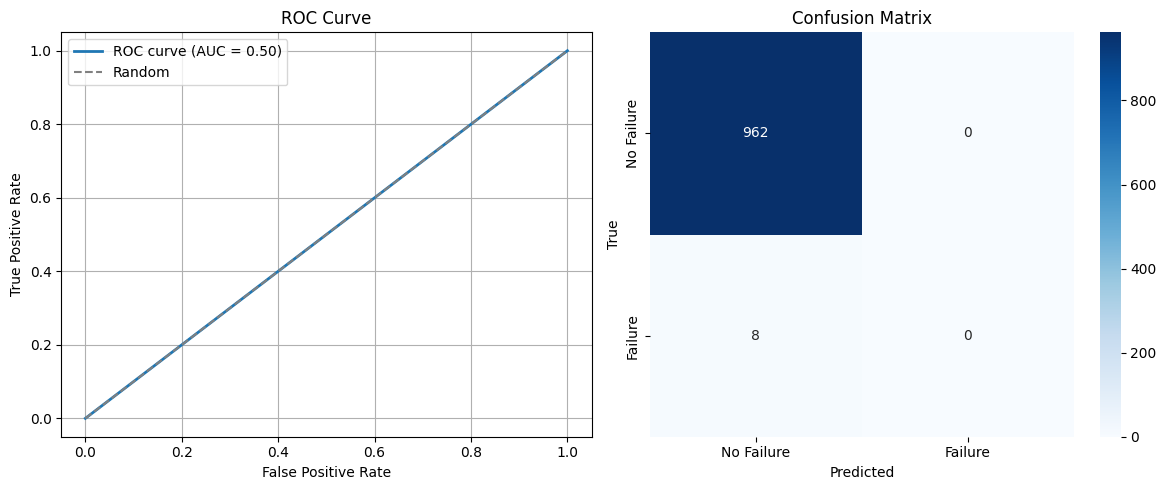

In [70]:
# Predict probabilities
y_pred_probs = model.predict(X_test).ravel()

# Call the function
plot_roc_and_confusion(y_test, y_pred_probs)

## B. With Sliding Windows and Oversampling (Enhanced Models)


### **B1.(Enhanced) LSTM**

**Model Architecture:**
- An LSTM model with 64 units and dropout regularization.
- Binary classification using sigmoid activation.
- Trained using binary cross-entropy loss and Adam optimizer.



In [85]:
X_balanced, y_balanced=create_sliding_windows_with_oversampling(df_binary)

X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, shuffle=True)

model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop])

eval_result = model.evaluate(X_test, y_test)
print(f"\n Evaluation: Loss={eval_result[0]:.4f}, Accuracy={eval_result[1]:.4f}, Precision={eval_result[2]:.4f}, Recall={eval_result[3]:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - accuracy: 0.7556 - loss: 0.5009 - precision_5: 0.7817 - recall_5: 0.7103 - val_accuracy: 0.9639 - val_loss: 0.1093 - val_precision_5: 0.9694 - val_recall_5: 0.9584
Epoch 2/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.9591 - loss: 0.1384 - precision_5: 0.9606 - recall_5: 0.9568 - val_accuracy: 0.9708 - val_loss: 0.0749 - val_precision_5: 0.9908 - val_recall_5: 0.9508
Epoch 3/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.9686 - loss: 0.0917 - precision_5: 0.9718 - recall_5: 0.9650 - val_accuracy: 0.9734 - val_loss: 0.0666 - val_precision_5: 0.9759 - val_recall_5: 0.9710
Epoch 4/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.9720 - loss: 0.0832 - precision_5: 0.9714 - recall_5: 0.9716 - val_accuracy: 0.9797 - val_loss: 0.0584 - val_precision_5: 0.9823 - val_recall_5: 0.9773
Epoch 5/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9781 - loss: 0.0664 - precision_5: 0.9797 - recall_5: 

In [86]:
# Predict probabilities
y_pred_probs = model.predict(X_test).ravel()
# Convert probabilities to class labels
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# Compute precision, recall, f1
precision = precision_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)

print(f"Precision (sklearn): {precision:.4f}")
print(f"Recall (sklearn): {recall:.4f}")
print(f"F1 Score (sklearn): {f1:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
Precision (sklearn): 0.9875
Recall (sklearn): 1.0000
F1 Score (sklearn): 0.9937


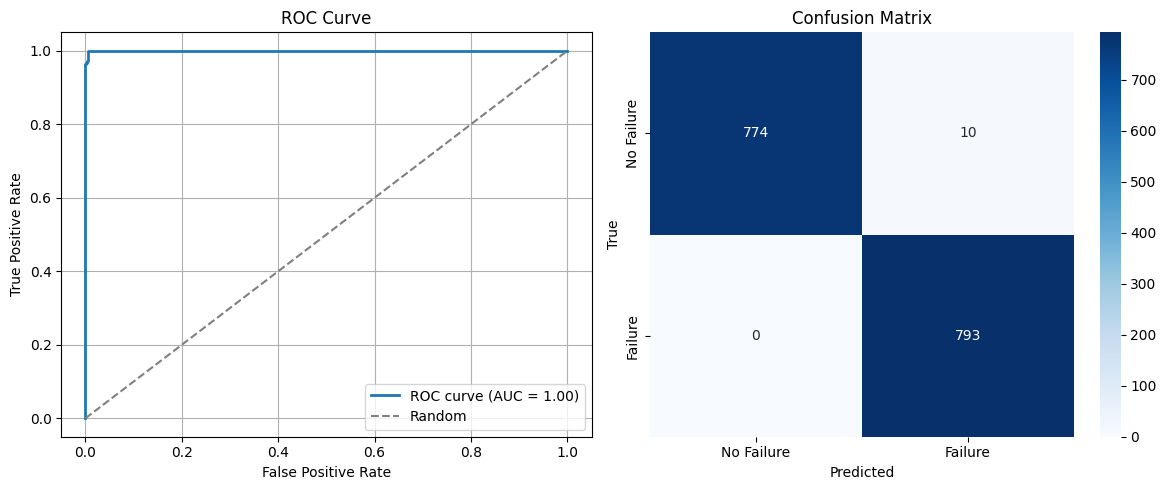

In [87]:
# Call the function
plot_roc_and_confusion(y_test, y_pred_probs)

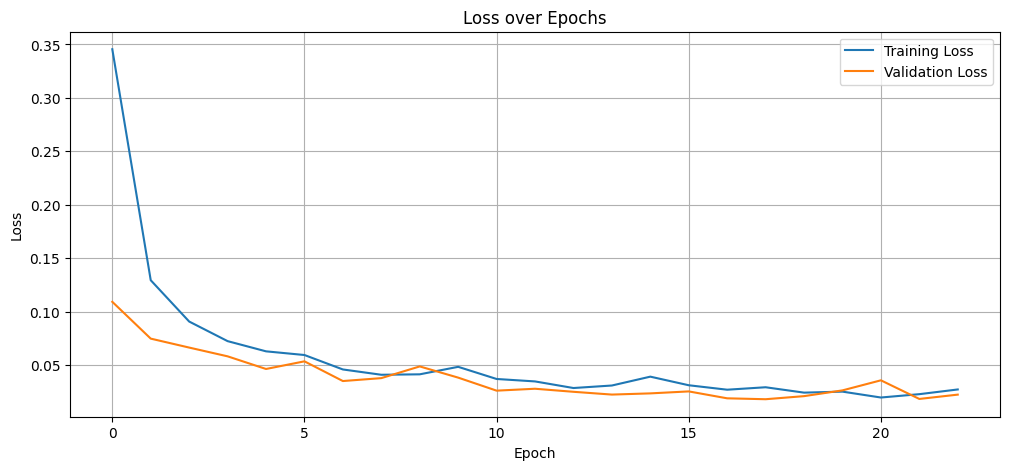

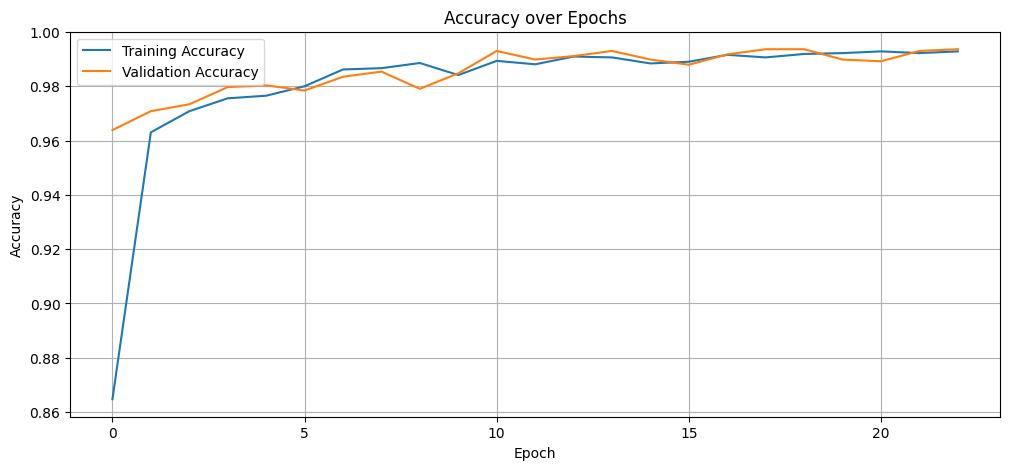

In [88]:
# --- Loss ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [76]:
y_pred_probs = model.predict(X_test)

y_pred = (y_pred_probs > 0.5).astype(int).flatten()

comparison_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred
})

comparison_df['Correct'] = comparison_df['True_Label'] == comparison_df['Predicted_Label']

failures_df = comparison_df[comparison_df['True_Label'] == 1]

print(failures_df)

failure_accuracy = (failures_df['Correct'].sum() / len(failures_df)) * 100
print(f" {failure_accuracy:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

      True_Label  Predicted_Label  Correct
0              1                1     True
1              1                1     True
3              1                1     True
7              1                1     True
10             1                1     True
...          ...              ...      ...
1564           1                1     True
1568           1                1     True
1571           1                1     True
1572           1                1     True
1575           1                1     True

[793 rows x 3 columns]
 99.12%


### **B2. (Enhanced) GRU**

**GRU Model Architecture:**
- A GRU layer with 64 units followed by dropout layers to reduce overfitting.
- A dense output layer with sigmoid activation for binary classification.

**Training and Evaluation:**
- Early stopping is applied to halt training when validation loss stops improving.



In [79]:
X_balanced, y_balanced=create_sliding_windows_with_oversampling(df_binary, multi_class=False)
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, shuffle=True)

GRU_model = Sequential([
    GRU(64, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    GRU(32, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

GRU_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = GRU_model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop])

eval_result = GRU_model.evaluate(X_test, y_test)
print(f"\n Evaluation: Loss={eval_result[0]:.4f}, Accuracy={eval_result[1]:.4f}, Precision={eval_result[2]:.4f}, Recall={eval_result[3]:.4f}")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


198/198 ━━━━━━━━━━━━━━━━━━━━ 25s 91ms/step - accuracy: 0.6846 - loss: 0.5719 - precision_4: 0.6429 - recall_4: 0.8819 - val_accuracy: 0.9309 - val_loss: 0.1932 - val_precision_4: 0.9329 - val_recall_4: 0.9294
Epoch 2/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.9358 - loss: 0.1951 - precision_4: 0.9282 - recall_4: 0.9439 - val_accuracy: 0.9816 - val_loss: 0.0521 - val_precision_4: 0.9787 - val_recall_4: 0.9849
Epoch 3/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.9675 - loss: 0.1060 - precision_4: 0.9596 - recall_4: 0.9764 - val_accuracy: 0.9677 - val_loss: 0.0794 - val_precision_4: 0.9818 - val_recall_4: 0.9533
Epoch 4/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9760 - loss: 0.0921 - precision_4: 0.9806 - recall_4: 0.9712 - val_accuracy: 0.9880 - val_loss: 0.0418 - val_precision_4: 0.9837 - val_recall_4: 0.9924
Epoch 5/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9816 - loss: 0.0617 - precision_4: 0.9764 - recall_4: 0.9864 - v

In [80]:
# Predict probabilities
y_pred_probs = model.predict(X_test).ravel()
# Convert probabilities to class labels
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# Compute precision, recall, f1
precision = precision_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)

print(f"Precision (sklearn): {precision:.4f}")
print(f"Recall (sklearn): {recall:.4f}")
print(f"F1 Score (sklearn): {f1:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Precision (sklearn): 0.9887
Recall (sklearn): 0.9912
F1 Score (sklearn): 0.9899


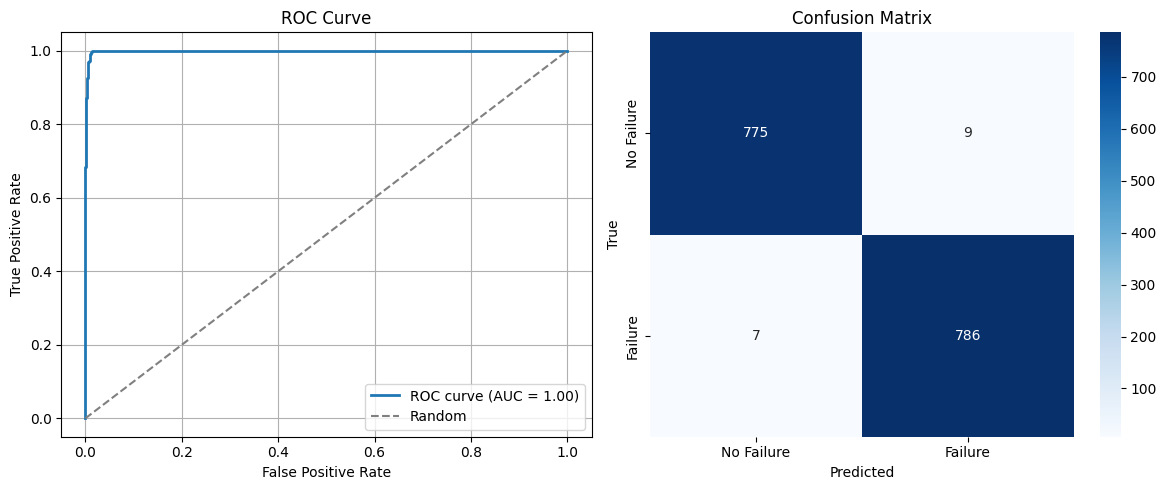

In [82]:
# Call the function
plot_roc_and_confusion(y_test, y_pred_probs)

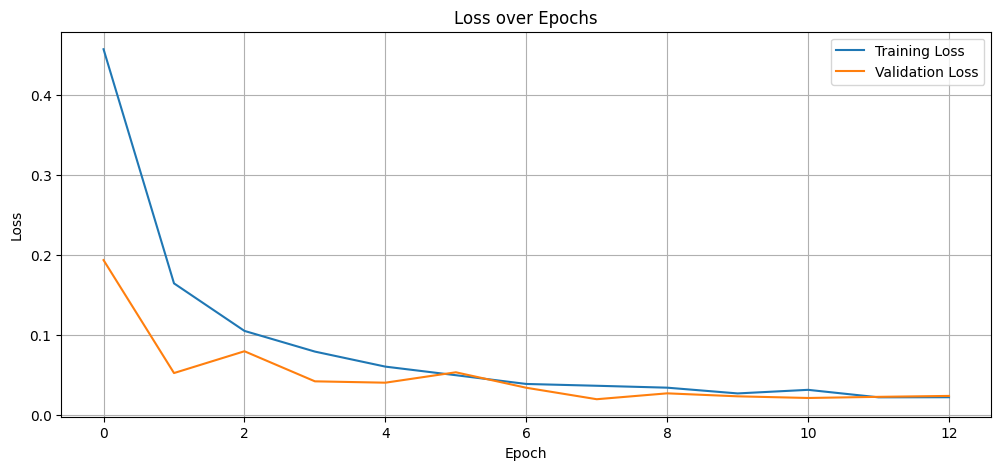

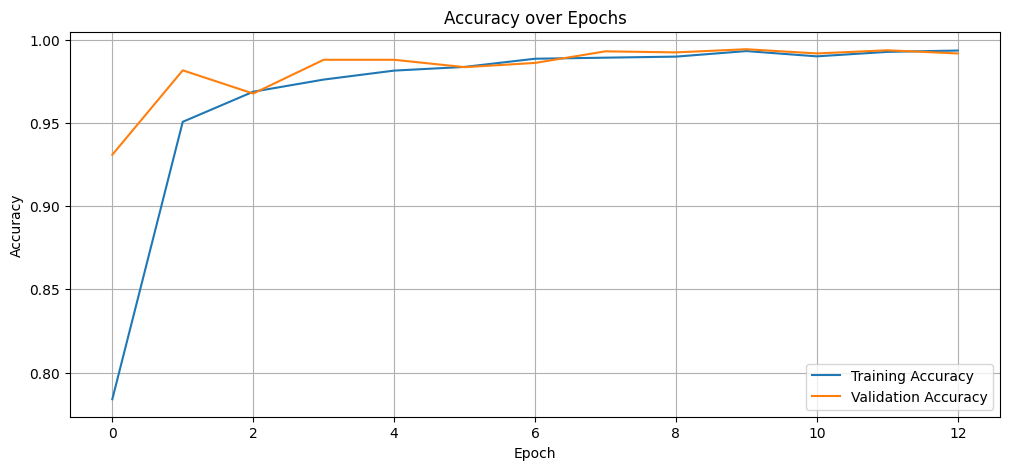

In [81]:
# --- Loss ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### **B3. (Enhanced) XGBoost**
**Model Training:**
- The data is split into training and testing sets (80/20).
- Only numerical features are used in the model.
- An `XGBClassifier` is trained with `eval_metric='logloss'`.




In [197]:
X_balanced, y_balanced=create_sliding_windows_with_oversampling(df_binary, multi_class=False)
X_balanced_flat = X_balanced.reshape((X_balanced.shape[0], -1))
X_train, X_test, y_train, y_test = train_test_split(X_balanced_flat, y_balanced, test_size=0.2, random_state=42, shuffle=True)


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_Xg = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                      scale_pos_weight=scale_pos_weight)


model_Xg.fit(X_train, y_train)

os.makedirs('models', exist_ok=True)
joblib.dump(model_Xg, 'models/model_Xg.pkl')

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:27:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


['models/model_Xg.pkl']

In [205]:
y_pred = model_Xg.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       784
           1       1.00      1.00      1.00       793

    accuracy                           1.00      1577
   macro avg       1.00      1.00      1.00      1577
weighted avg       1.00      1.00      1.00      1577



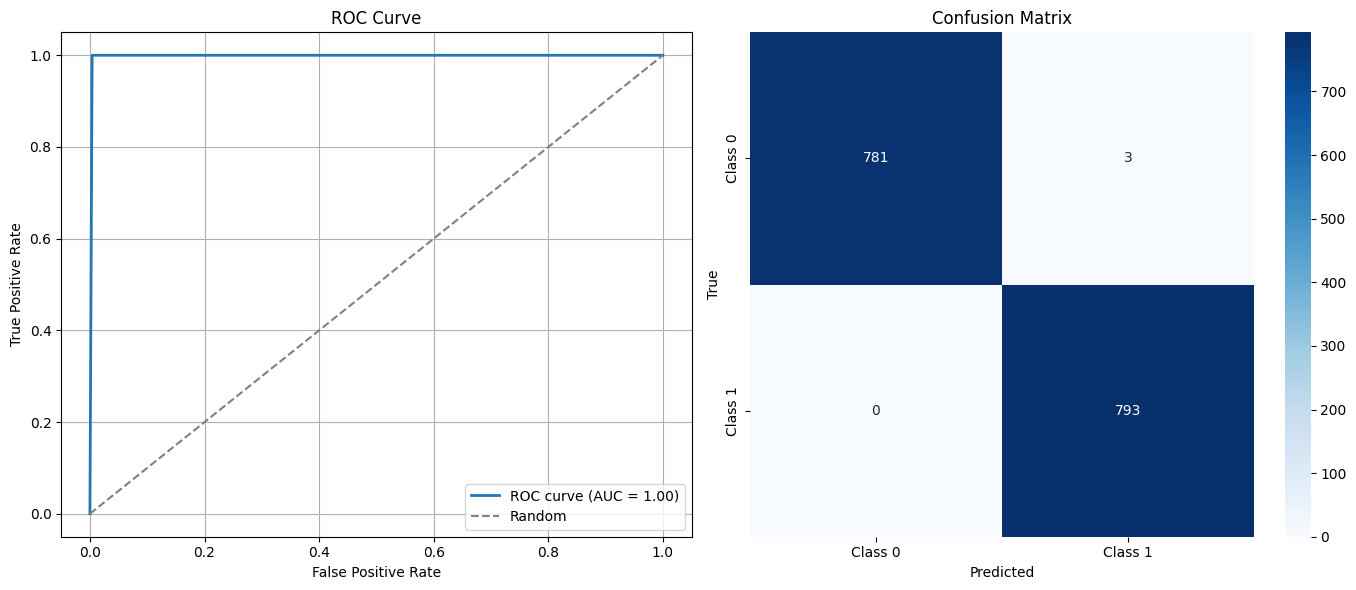

In [207]:
# Call the function
plot_roc_and_confusion(y_test, y_pred)

### **B4. (Enhanced) RF**




In [94]:
X_balanced, y_balanced=create_sliding_windows_with_oversampling(df_binary, multi_class=False)
X_balanced_flat = X_balanced.reshape((X_balanced.shape[0], -1))
X_train, X_test, y_train, y_test = train_test_split(X_balanced_flat, y_balanced, test_size=0.2, random_state=42, shuffle=True)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [95]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       784
           1       1.00      1.00      1.00       793

    accuracy                           1.00      1577
   macro avg       1.00      1.00      1.00      1577
weighted avg       1.00      1.00      1.00      1577



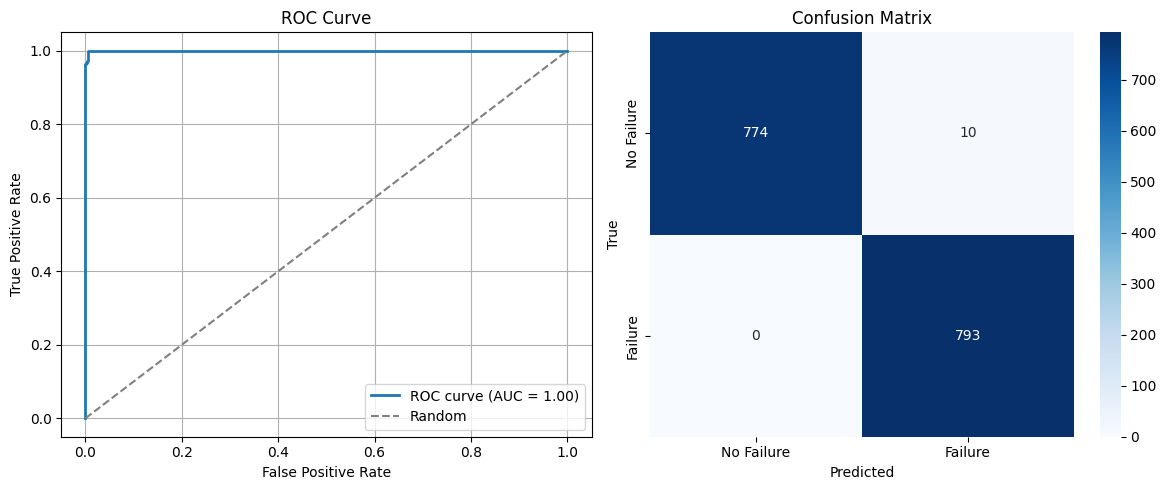

In [96]:
# Call the function
plot_roc_and_confusion(y_test, y_pred)

# **Stage 2: Multi-Class Failure Classification**

In this stage, we go beyond simple failure detection and aim to **classify the specific type of failure** that an engine may experience. This is a more complex task compared to binary classification, as the model must learn to distinguish between multiple failure modes.

---

## Objective

Instead of predicting just `failure` or `no failure`, we now classify among several types of failures:

- **Class 0**: No failure  
- **Class 1**: Turbocharger  
- **Class 2**: Power Assembly  
- **Class 3**: SRS_TRS  
- **Class 4**: Injector  

---

## Modeling Approach

We use the following pipeline:
1. **Sliding Window Segmentation** of time-series sensor data  
2. **Oversampling** to balance the class distribution across all failure types  
3. **Evaluation** using metrics tailored for multi-class:
   - Confusion matrix  
   - Accuracy /Precision / Recall / F1-Score **Per-class**
   - One-vs-all **ROC curve & AUC**

---

## Evaluation Focus

Because some failure classes have very few samples, we also track:
- Whether the model can **correctly classify failure vs. no failure**
- Whether it can **differentiate between failure types**


## **Multi-Class LSTM Model**

### **Model Architecture**
- 2 LSTM layers with dropout for regularization.
- Final dense output layer with `softmax` activation for multi-class classification.
- Loss function: `categorical_crossentropy`



In [122]:
X_balanced, y_balanced = create_sliding_windows_with_oversampling(df_balance,multi_class=True )
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

n_classes = np.max(y_balanced) + 1

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.3),
    LSTM(32, activation='tanh'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop])
eval_result = model.evaluate(X_test, y_test)
print(f"\n Evaluation: Loss={eval_result[0]:.4f}, Accuracy={eval_result[1]:.4f}")


Epoch 1/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 36s 64ms/step - accuracy: 0.7868 - loss: 0.6509 - val_accuracy: 0.9201 - val_loss: 0.4453
Epoch 2/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.9578 - loss: 0.1536 - val_accuracy: 0.9853 - val_loss: 0.0445
Epoch 3/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9750 - loss: 0.0945 - val_accuracy: 0.9893 - val_loss: 0.0299
Epoch 4/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9823 - loss: 0.0696 - val_accuracy: 0.9964 - val_loss: 0.0189
Epoch 5/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.9891 - loss: 0.0461 - val_accuracy: 0.9959 - val_loss: 0.0168
Epoch 6/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.9902 - loss: 0.0430 - val_accuracy: 0.9896 - val_loss: 0.0298
Epoch 7/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.9887 - loss: 0.0435 - val_accuracy: 0.9876 - val_loss: 0.0345
Epoch 8/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.9878 - loss: 0.0444 - 

In [123]:
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Precision/Recall/F1
precision = precision_score(y_test, y_pred_classes, average='macro')
recall = recall_score(y_test, y_pred_classes, average='macro')
f1 = f1_score(y_test, y_pred_classes, average='macro')

print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")


124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Precision: 0.9987, Recall: 0.9987, F1: 0.9987


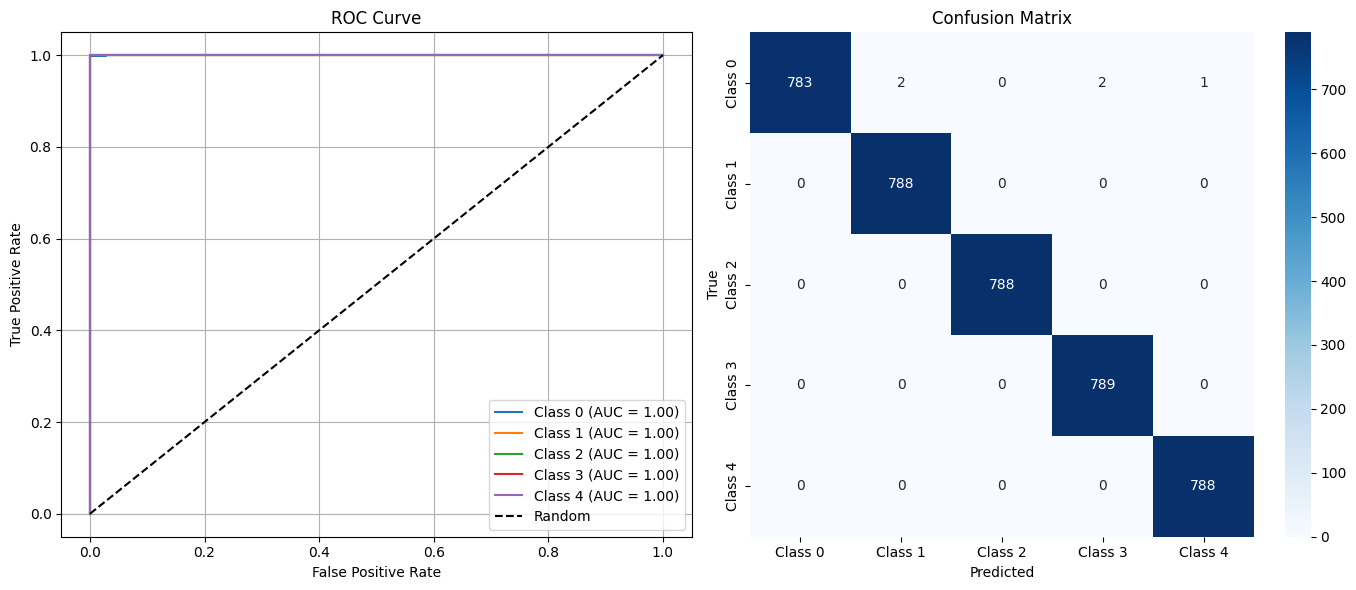

In [124]:
# Call the function
plot_roc_and_confusion(y_test, y_pred_probs)

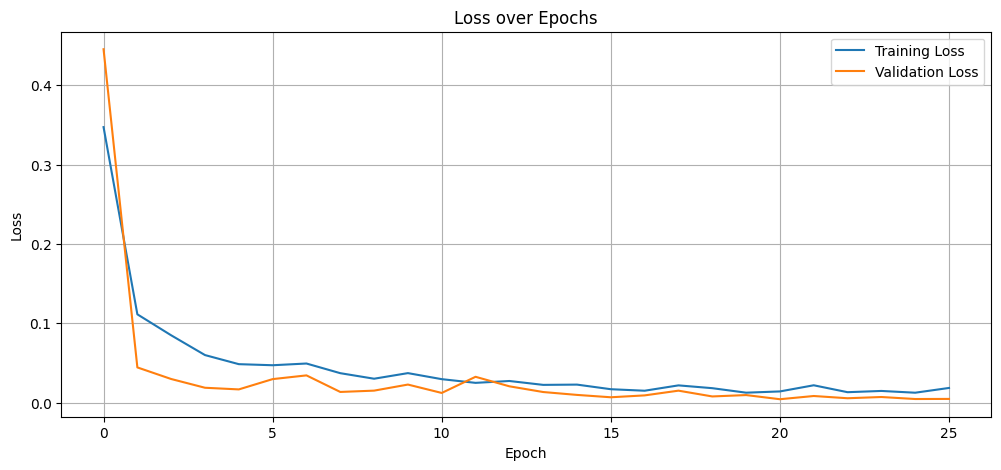

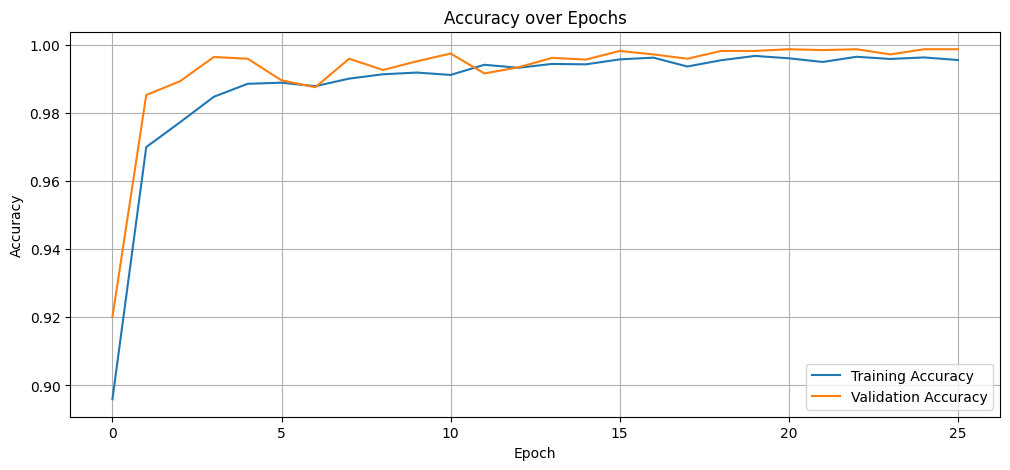

In [125]:
# --- Loss ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## **Multi-Class: GRU Model**

### **Model Details**
- GRU layers used for capturing temporal patterns.
- Final dense layer with `softmax` activation for classification.
- Loss: `categorical_crossentropy`



In [126]:
X_balanced, y_balanced = create_sliding_windows_with_oversampling(df_balance,multi_class=True )
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

n_classes = np.max(y_balanced) + 1

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(64, activation='tanh', return_sequences=True),
    Dropout(0.3),
    GRU(32, activation='tanh'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop])

eval_result = model.evaluate(X_test, y_test)
print(f"\n Evaluation: Loss={eval_result[0]:.4f}, Accuracy={eval_result[1]:.4f}")


Epoch 1/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.7371 - loss: 0.7299 - val_accuracy: 0.9716 - val_loss: 0.0912
Epoch 2/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.9645 - loss: 0.1189 - val_accuracy: 0.9888 - val_loss: 0.0314
Epoch 3/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.9843 - loss: 0.0567 - val_accuracy: 0.9967 - val_loss: 0.0118
Epoch 4/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.9861 - loss: 0.0497 - val_accuracy: 0.9911 - val_loss: 0.0232
Epoch 5/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9910 - loss: 0.0373 - val_accuracy: 0.9929 - val_loss: 0.0178
Epoch 6/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.9916 - loss: 0.0303 - val_accuracy: 0.9967 - val_loss: 0.0104
Epoch 7/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9944 - loss: 0.0246 - val_accuracy: 0.9980 - val_loss: 0.0082
Epoch 8/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.9939 - loss: 0.0235 - 

In [127]:
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Precision/Recall/F1
precision = precision_score(y_test, y_pred_classes, average='macro')
recall = recall_score(y_test, y_pred_classes, average='macro')
f1 = f1_score(y_test, y_pred_classes, average='macro')

print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")


124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
Precision: 0.9992, Recall: 0.9992, F1: 0.9992


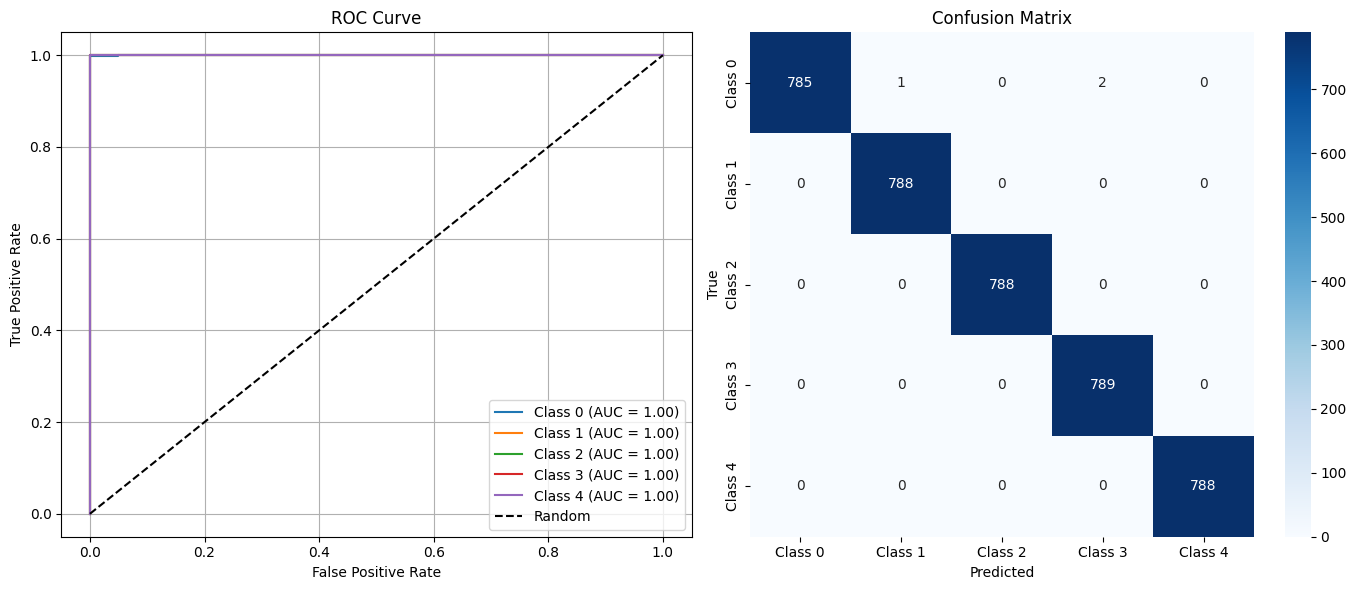

In [128]:
# Call the function
plot_roc_and_confusion(y_test, y_pred_probs)

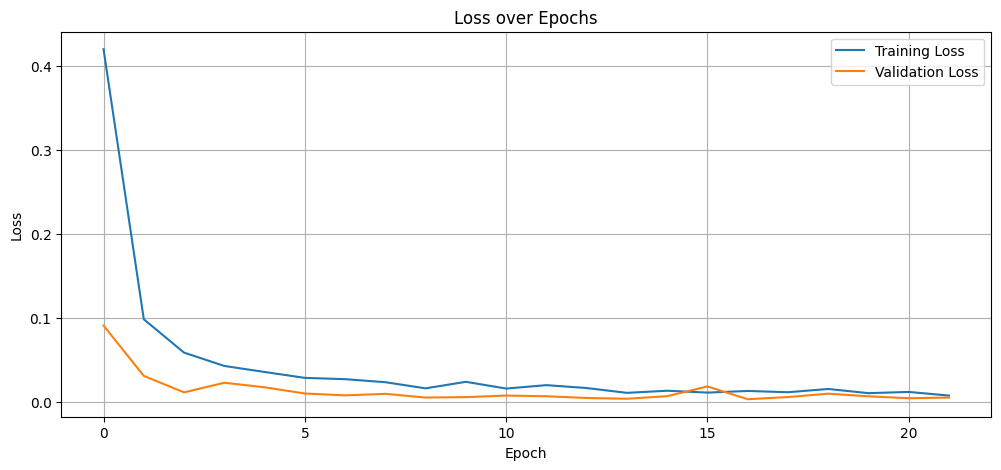

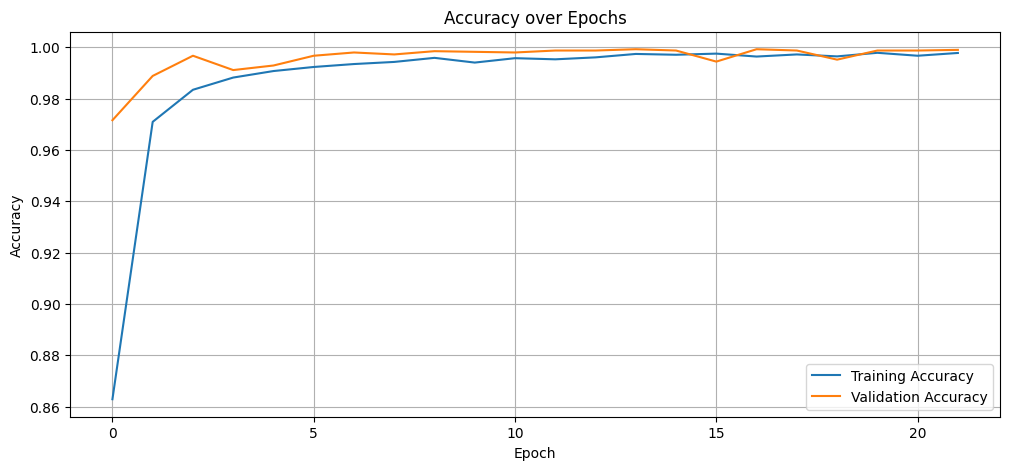

In [129]:
# --- Loss ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## **Multi-Class: XGBoost Model**

### **Model Details**
- Traditional gradient boosting model (XGBoost).
- Trained with softmax objective for multi-class classification.




In [118]:
X_balanced, y_balanced = create_sliding_windows_with_oversampling(df_balance,multi_class=True )
X_flattened = X_balanced.reshape((X_balanced.shape[0], -1))  # Flatten for tree-based models
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:50:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       788
           1       1.00      1.00      1.00       788
           2       1.00      1.00      1.00       788
           3       1.00      1.00      1.00       789
           4       1.00      1.00      1.00       788

    accuracy                           1.00      3941
   macro avg       1.00      1.00      1.00      3941
weighted avg       1.00      1.00      1.00      3941



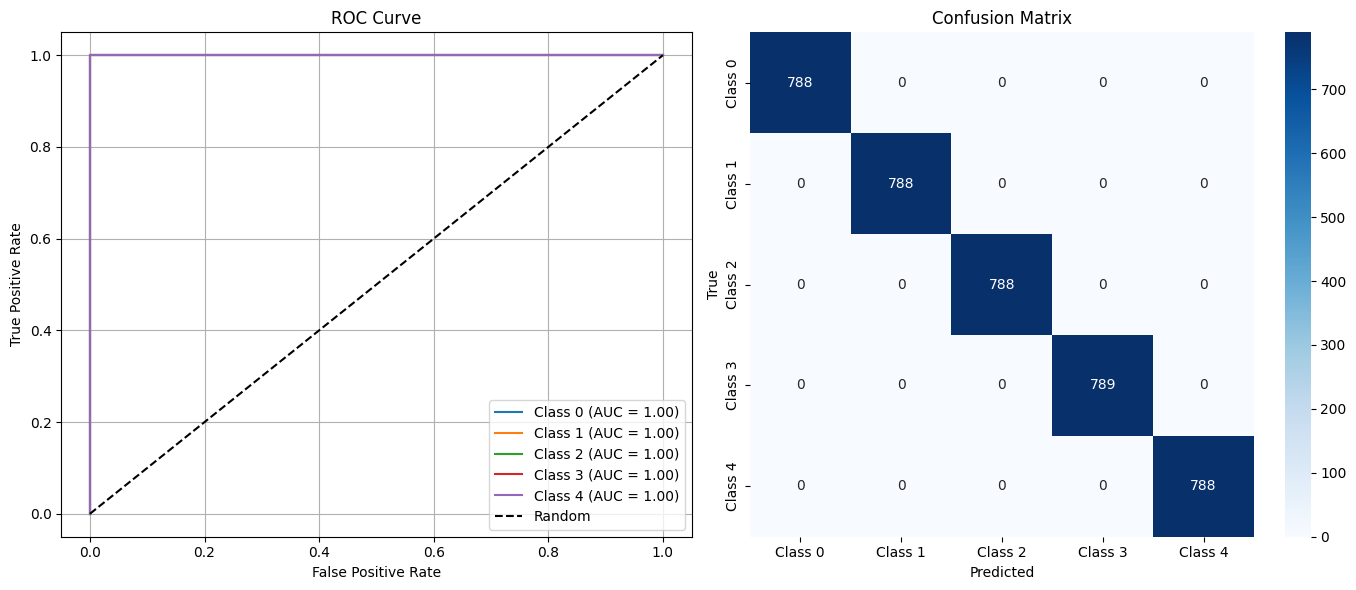

In [119]:
y_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred))
y_pred_probs = xgb_model.predict_proba(X_test)
plot_roc_and_confusion(y_test, y_pred_probs)


## **Multi-Class: Random Forest Model**

### **Model Details**
- Classic ensemble tree-based model.
- Trained with balanced class distribution using oversampling.



In [212]:
X_balanced, y_balanced = create_sliding_windows_with_oversampling(df_balance,multi_class=True )
X_flattened = X_balanced.reshape((X_balanced.shape[0], -1))  # Flatten for tree-based models
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
joblib.dump(rf_model, 'models/rf_model.pkl')

['models/rf_model.pkl']

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       788
           1       1.00      1.00      1.00       788
           2       1.00      1.00      1.00       788
           3       1.00      1.00      1.00       789
           4       1.00      1.00      1.00       788

    accuracy                           1.00      3941
   macro avg       1.00      1.00      1.00      3941
weighted avg       1.00      1.00      1.00      3941



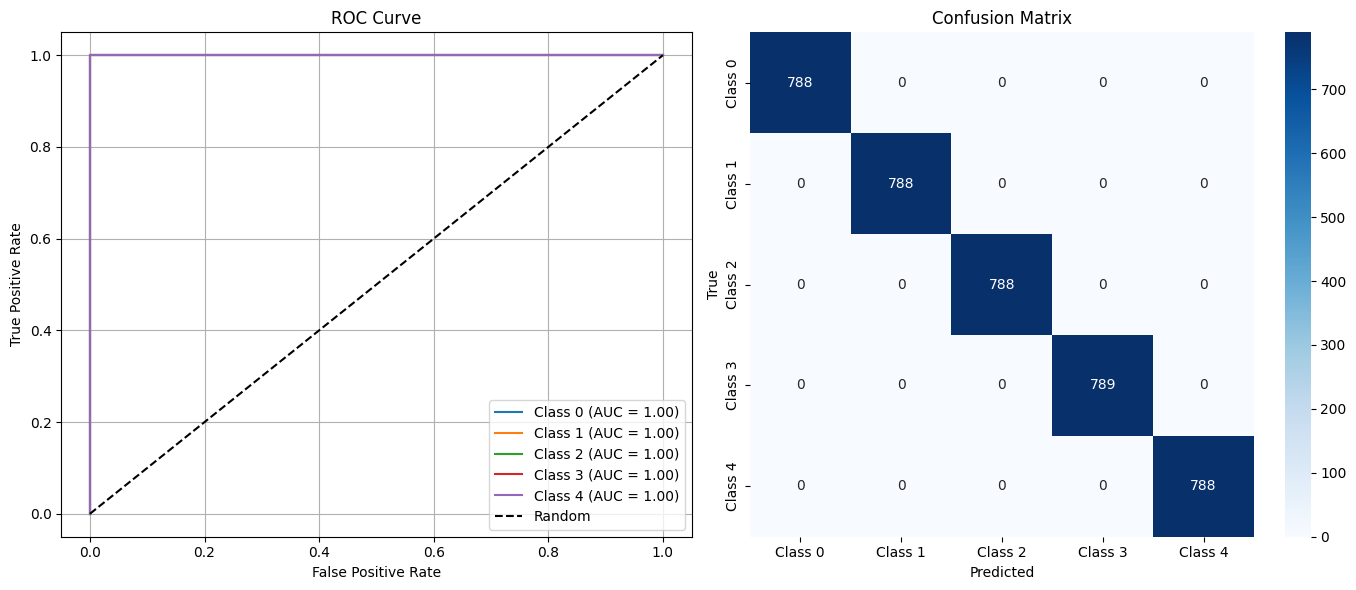

In [214]:
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))
y_pred_probs = rf_model.predict_proba(X_test)
plot_roc_and_confusion(y_test, y_pred_probs)


# **Stage 3: Degradation Score Prediction and Maintenance State Mapping**

In this stage, the modeling goal focuses on predicting a continuous degradation score rather than direct multi-class classification.
The model outputs a continuous degradation score reflecting the engine's health condition.
This score is post-processed into one of three maintenance states using predefined thresholds:

- **Normal**: Engine operating within healthy limits (score ≤ 0.4)
- **Maintenance Soon**: Engine starting to show degradation (0.4 < score ≤ 0.7)
- **Failure Imminent**: Engine nearing failure condition (score > 0.7)


---
The following deep learning models are evaluated:

- **Model 1**: LSTM-based degradation prediction  
- **Model 2**: GRU-based degradation prediction  


---

## **Evaluation Metrics**

Each model is evaluated using:
- **MSE/MAE/RMSE**
- **Confusion Matrix**
- **Degradation Timeline Plot**  
  (shows predicted scores over time with color-coded maintenance zones)

These evaluations help us understand how well each model detects early signs of failure and supports preventive maintenance.


In [190]:
def split_engines(df):
    boundaries = df[(df.select_dtypes(include=[np.number]) == 0).all(axis=1)].index.tolist()
    boundaries = [-1] + boundaries + [len(df)]
    engines = []
    for i in range(len(boundaries)-1):
        start = boundaries[i] + 1
        end = boundaries[i+1]
        chunk = df.iloc[start:end].copy()
        if not chunk.empty:
            engines.append(chunk.reset_index(drop=True))
    return engines

def prepare_sequences(engines, seq_length=30):
    X_all, y_all = [], []
    for engine in engines:
        engine = engine.select_dtypes(include=[np.number])
        if len(engine) <= seq_length:
            continue
        for i in range(len(engine) - seq_length):
            seq = engine.iloc[i:i+seq_length].values
            target = i / (len(engine) - seq_length)
            X_all.append(seq)
            y_all.append(target)
    return np.array(X_all), np.array(y_all)


def scale_sequences(X, scaler=None):
    if scaler is None:
        scaler = MinMaxScaler()
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = scaler.fit_transform(X_reshaped)
    else:
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = scaler.transform(X_reshaped)
    X_scaled = X_scaled.reshape(X.shape)
    return X_scaled, scaler

def build_lstm_model_v1(input_shape):
    model = Sequential([
        LSTM(32, input_shape=input_shape, return_sequences=False, dropout=0.2, recurrent_dropout=0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

def build_lstm_model_v1(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True, dropout=0.3),
        LSTM(32, dropout=0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')
    return model

def build_lstm_model_v2(input_shape):
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=False),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.0008), loss='mse')
    return model


def build_lstm_model_v3(input_shape):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        Dropout(0.3),
        Bidirectional(LSTM(32, recurrent_dropout=0.2)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=RMSprop(learning_rate=0.001), loss='mse')
    return model

def build_gru_model_v1(input_shape):
    model = Sequential([
        GRU(64, input_shape=input_shape, return_sequences=True, dropout=0.3),
        GRU(32, dropout=0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')
    return model

def build_gru_model_v2(input_shape):
    model = Sequential([
        GRU(128, input_shape=input_shape, return_sequences=False),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.0008), loss='mse')
    return model


def build_gru_model_v3(input_shape):
    model = Sequential([
        Bidirectional(GRU(64, return_sequences=True, recurrent_dropout=0.2), input_shape=input_shape),
        Dropout(0.3),
        Bidirectional(GRU(32, recurrent_dropout=0.2)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Nadam(learning_rate=0.001), loss='mse')
    return model

def train_model(model, X, y, epochs=20, batch_size=64):
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=1)
    return history

def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print("\n\nModel Evaluation Metrics:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")


def label_maintenance(y_values):
    labels = []
    for val in y_values:
        if val <= 0.4:
            labels.append("Normal")
        elif val <= 0.7:
            labels.append("Maintenance Soon")
        else:
            labels.append("Failure Imminent")
    return labels

def plot_sample_engine(engine_df, model, scaler, seq_length=30):
    engine_numeric = engine_df.select_dtypes(include=[np.number])
    sample_X = []
    for i in range(len(engine_numeric) - seq_length):
        seq = engine_numeric.iloc[i:i+seq_length].values
        sample_X.append(seq)
    sample_X = np.array(sample_X)
    sample_X_scaled = scaler.transform(sample_X.reshape(-1, sample_X.shape[-1]))
    sample_X_scaled = sample_X_scaled.reshape(sample_X.shape)

    predictions = model.predict(sample_X_scaled)

    # Visualization
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(predictions)), predictions, label='Predicted Degradation')
    plt.title("Degradation Prediction Timeline with Maintenance States")
    plt.xlabel("Time Step")
    plt.ylabel("Predicted Degradation")
    plt.grid(True)

    colors = {'Normal': 'green', 'Maintenance Soon': 'orange', 'Failure Imminent': 'red'}
    maintenance_labels = label_maintenance(predictions.flatten())
    for i, (pred, label) in enumerate(zip(predictions, maintenance_labels)):
        plt.scatter(i, pred, color=colors[label], s=10)

    plt.legend()
    plt.tight_layout()
    plt.show()


## **Model 1**: LSTM-based degradation prediction  


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.1525
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0881
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0857
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0858
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0832
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0835
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0834
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0838
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0837
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0847
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0823
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0813
Epoch 13/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0834
Epoch 14/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0833
Epoch 15/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0821
Epoch 16/20
63/

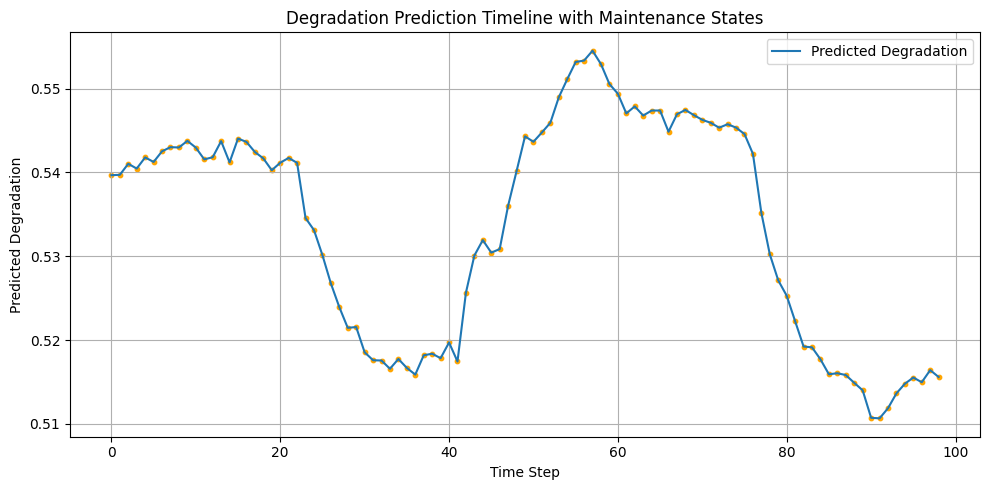

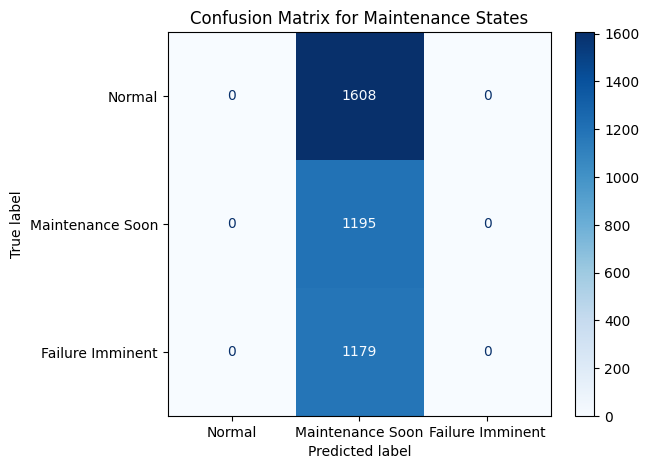

In [168]:
engines = split_engines(df_filtered)
X, y = prepare_sequences(engines, seq_length=30)

X_scaled, scaler = scale_sequences(X)

model = build_lstm_model_v1(input_shape=(X.shape[1], X.shape[2]))
train_model(model, X_scaled, y, epochs=20, batch_size=64)

y_pred = model.predict(X_scaled).flatten()
evaluate_regression(y, y_pred)

plot_sample_engine(engines[0], model, scaler, seq_length=30)

true_labels = label_maintenance(y)
pred_labels = label_maintenance(y_pred)

labels_order = ["Normal", "Maintenance Soon", "Failure Imminent"]
cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)
cmd = ConfusionMatrixDisplay(cm, display_labels=labels_order)
cmd.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Maintenance States")
plt.tight_layout()
plt.show()



### LSTM-based degradation prediction  **(hyperparameters tuning)**

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.1902
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0846
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0800
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 0.0787
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0725
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0672
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.0657
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0558
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0433
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0380
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0376
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0283
Epoch 13/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0267
Epoch 14/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0326
Epoch 15/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0249
Epoch 16/20
63/

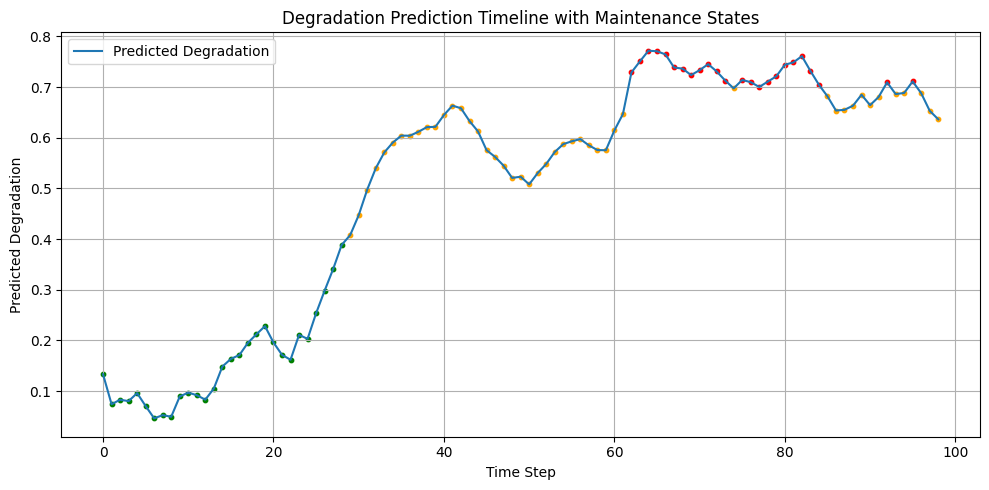

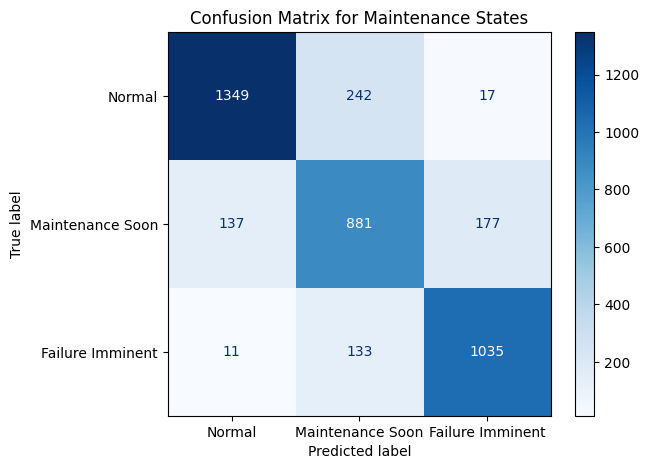

In [169]:
engines = split_engines(df_filtered)
X, y = prepare_sequences(engines, seq_length=30)

X_scaled, scaler = scale_sequences(X)

model = build_lstm_model_v2(input_shape=(X.shape[1], X.shape[2]))
train_model(model, X_scaled, y, epochs=20, batch_size=64)

y_pred = model.predict(X_scaled).flatten()
evaluate_regression(y, y_pred)

plot_sample_engine(engines[0], model, scaler, seq_length=30)

true_labels = label_maintenance(y)
pred_labels = label_maintenance(y_pred)

labels_order = ["Normal", "Maintenance Soon", "Failure Imminent"]
cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)
cmd = ConfusionMatrixDisplay(cm, display_labels=labels_order)
cmd.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Maintenance States")
plt.tight_layout()
plt.show()



Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - loss: 0.1361
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - loss: 0.0909
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0873
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.0870
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - loss: 0.0853
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - loss: 0.0788
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 0.0796
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 133ms/step - loss: 0.0747
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - loss: 0.0680
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 297ms/step - loss: 0.0687
Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 0.0623
Epoch 12/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 0.0565
Epoch 13/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.0575
Epoch 14/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.0561
Epoch 15/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step - loss:

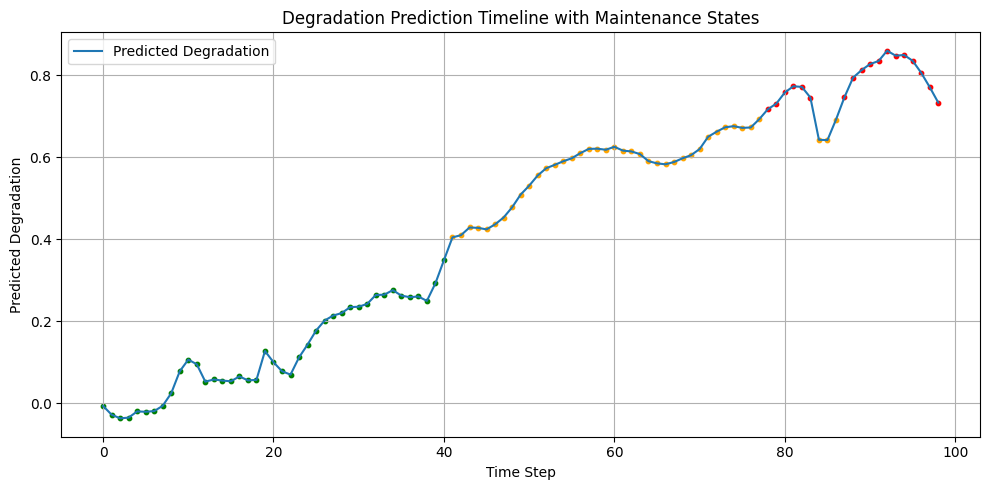

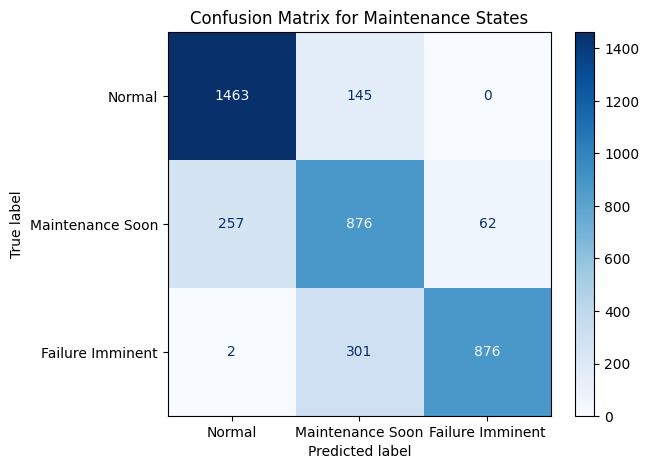

In [191]:
engines = split_engines(df_filtered)
X, y = prepare_sequences(engines, seq_length=30)

X_scaled, scaler = scale_sequences(X)

model = build_lstm_model_v3(input_shape=(X.shape[1], X.shape[2]))
train_model(model, X_scaled, y, epochs=50, batch_size=64)

y_pred = model.predict(X_scaled).flatten()
evaluate_regression(y, y_pred)

plot_sample_engine(engines[0], model, scaler, seq_length=30)

true_labels = label_maintenance(y)
pred_labels = label_maintenance(y_pred)

labels_order = ["Normal", "Maintenance Soon", "Failure Imminent"]
cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)
cmd = ConfusionMatrixDisplay(cm, display_labels=labels_order)
cmd.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Maintenance States")
plt.tight_layout()
plt.show()



## **Model 2**: GRU-based degradation prediction  


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.2287
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.1083
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.0920
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0890
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0849
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.0860
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0848
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0870
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0836
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0824
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0860
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0836
Epoch 13/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.0869
Epoch 14/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0811
Epoch 15/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0823
Epoch 16/20
63/

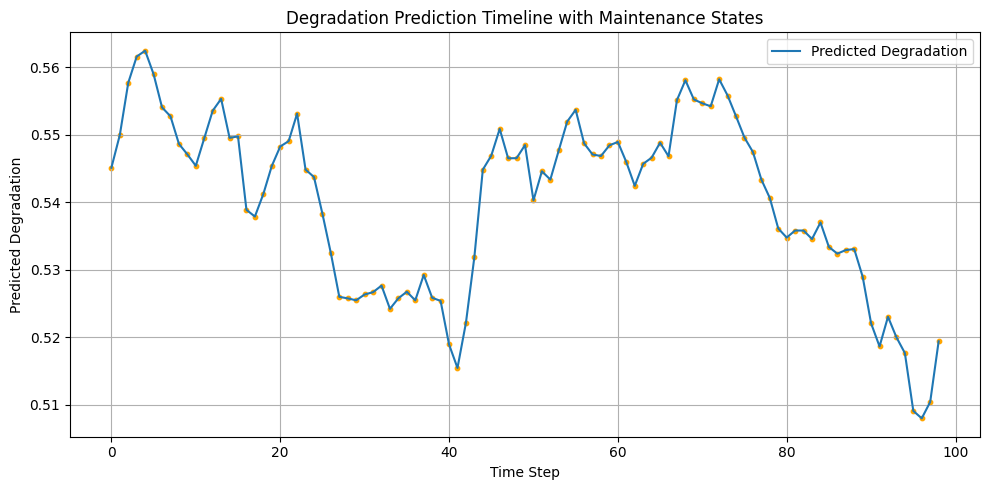

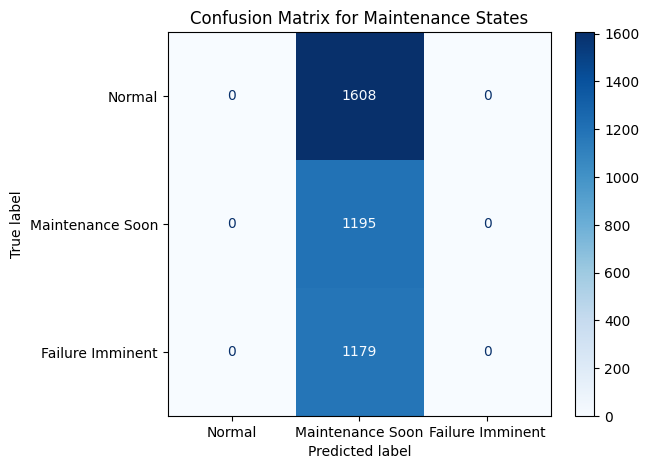

In [189]:
engines = split_engines(df_filtered)
X, y = prepare_sequences(engines, seq_length=30)

X_scaled, scaler = scale_sequences(X)

gru_model = build_gru_model_v1(input_shape=(X.shape[1], X.shape[2]))
train_model(gru_model, X_scaled, y, epochs=20, batch_size=64)

y_pred_gru = gru_model.predict(X_scaled).flatten()
evaluate_regression(y, y_pred_gru)

plot_sample_engine(engines[0], gru_model, scaler, seq_length=30)

true_labels = label_maintenance(y)
pred_labels = label_maintenance(y_pred_gru)

labels_order = ["Normal", "Maintenance Soon", "Failure Imminent"]
cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)
cmd = ConfusionMatrixDisplay(cm, display_labels=labels_order)
cmd.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Maintenance States")
plt.tight_layout()
plt.show()



### GRU-based degradation prediction  **(hyperparameters tuning)**

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.1200
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 0.0798
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0752
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0676
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.0665
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0573
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - loss: 0.0537
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0482
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0539
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0372
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - loss: 0.0373
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0328
Epoch 13/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0329
Epoch 14/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0286
Epoch 15/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - loss: 0.0241
Epoch 16/20
6

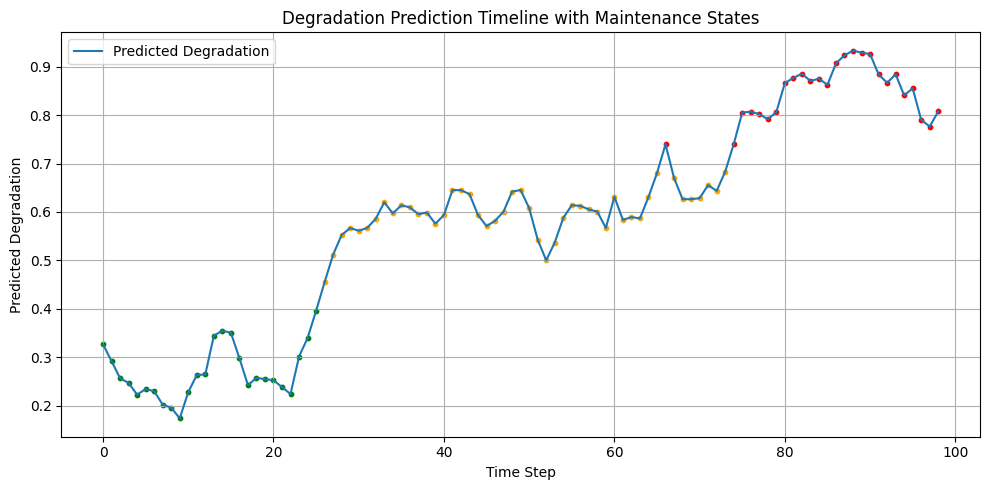

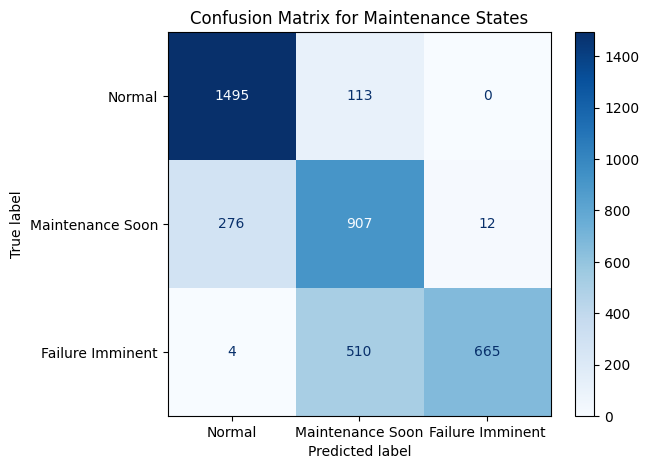

In [188]:
engines = split_engines(df_filtered)
X, y = prepare_sequences(engines, seq_length=30)

X_scaled, scaler = scale_sequences(X)

gru_model = build_gru_model_v2(input_shape=(X.shape[1], X.shape[2]))
train_model(gru_model, X_scaled, y, epochs=20, batch_size=64)

y_pred_gru = gru_model.predict(X_scaled).flatten()
evaluate_regression(y, y_pred_gru)

plot_sample_engine(engines[0], gru_model, scaler, seq_length=30)

true_labels = label_maintenance(y)
pred_labels = label_maintenance(y_pred_gru)

labels_order = ["Normal", "Maintenance Soon", "Failure Imminent"]
cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)
cmd = ConfusionMatrixDisplay(cm, display_labels=labels_order)
cmd.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Maintenance States")
plt.tight_layout()
plt.show()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 187ms/step - loss: 0.1244
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 191ms/step - loss: 0.0908
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - loss: 0.0869
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - loss: 0.0820
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 280ms/step - loss: 0.0787
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 266ms/step - loss: 0.0739
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 137ms/step - loss: 0.0731
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 206ms/step - loss: 0.0741
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 159ms/step - loss: 0.0666
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 224ms/step - loss: 0.0620
Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - loss: 0.0616
Epoch 12/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 264ms/step - loss: 0.0610
Epoch 13/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 369ms/step - loss: 0.0522
Epoch 14/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 178ms/step - loss: 0.0488
Epoch 15/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 

125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step


Model Evaluation Metrics:
MAE: 0.0738
MSE: 0.0100
RMSE: 0.1002
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


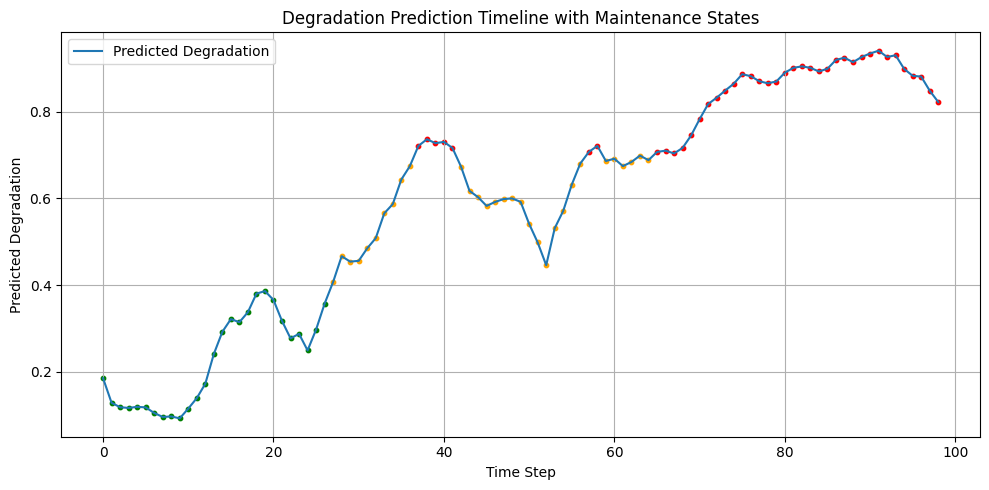

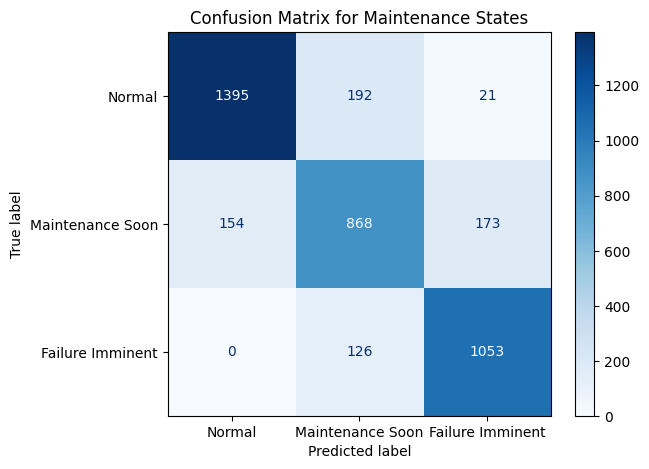

In [218]:
engines = split_engines(df_filtered)
X, y = prepare_sequences(engines, seq_length=30)

X_scaled, scaler = scale_sequences(X)
joblib.dump(scaler, 'models/GRU_scaler.pkl')
gru_model = build_gru_model_v3(input_shape=(X.shape[1], X.shape[2]))
train_model(gru_model, X_scaled, y, epochs=50, batch_size=64)

gru_model.save('models/GRU_model.h5')

y_pred_gru = gru_model.predict(X_scaled).flatten()
evaluate_regression(y, y_pred_gru)

plot_sample_engine(engines[0], gru_model, scaler, seq_length=30)

true_labels = label_maintenance(y)
pred_labels = label_maintenance(y_pred_gru)

labels_order = ["Normal", "Maintenance Soon", "Failure Imminent"]
cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)
cmd = ConfusionMatrixDisplay(cm, display_labels=labels_order)
cmd.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Maintenance States")
plt.tight_layout()
plt.show()



# Pipline

In [224]:
class Stage1BinaryClassifier:
    def __init__(self, model, feature_columns):
        self.model = model
        self.feature_columns = feature_columns

    def predict(self, X_query):
        X_numeric = X_query[self.feature_columns].select_dtypes(exclude='object')
        pred = self.model.predict(X_numeric)
        return int(pred[0])  # 0 or 1

class Stage2MultiClassifier:
    def __init__(self, model):
        self.model = model

    def predict(self, X_query):
        X_flattened = X_query.values.reshape(1, -1)
        pred = self.model.predict(X_flattened)
        return int(pred[0])

class Stage3DegradationModel:
    def __init__(self, model, scaler, seq_length=30):
        self.model = model
        self.scaler = scaler
        self.seq_length = seq_length

    def predict(self, X_window):
        if len(X_window) < self.seq_length:
            raise ValueError(f"❌ Need at least {self.seq_length} rows for LSTM input (currently {len(X_window)})")

        last_seq = X_window[-self.seq_length:].values
        last_seq_scaled = self.scaler.transform(last_seq)
        last_seq_scaled = last_seq_scaled.reshape(1, self.seq_length, last_seq.shape[1])

        degradation_score = self.model.predict(last_seq_scaled)[0][0]

        if degradation_score <= 0.4:
            status = "Normal"
        elif degradation_score <= 0.7:
            status = "Maintenance Soon"
        else:
            status = "Failure Imminent"

        return {
            'degradation_score': float(degradation_score),
            'maintenance_status': status
        }



In [249]:
xgb_model = joblib.load('models/model_Xg.pkl')
rf_model = joblib.load('models/rf_model.pkl')
GRU_model = load_model('models/GRU_model.h5', compile=False)
GRU_model.compile(optimizer='adam', loss=MeanSquaredError())
scaler = joblib.load('models/GRU_scaler.pkl')

# Prepare columns
feature_cols_stage1 = df_balance.columns.drop(['failure_type', 'Time Stamp', 'Asset Name'], errors='ignore')
df = df_balance.copy()

# Set window size
window_size = 30

# Random query (unseen sample)
random_row = df.sample(1)[feature_cols_stage1]

# Create sliding window (30 rows) by duplicating random row
query_stage1_window = pd.concat([random_row]*window_size, ignore_index=True)

# Flatten the window → must match model input shape
query_stage1_flat = query_stage1_window.values.flatten().reshape(1, -1)

print(f"Stage 1 query shape: {query_stage1_flat.shape}")

# Prepare Stage 3 window (actual last 30 rows)
query_stage3_window_df = df[feature_cols_stage1].tail(window_size)

# Define your pipeline stages
stage1 = Stage1BinaryClassifier(xgb_model, feature_cols_stage1)
stage2 = Stage2MultiClassifier(rf_model)
stage3 = Stage3DegradationModel(GRU_model, scaler)

# Run pipeline
print("Running Stage 1...")

# Make sure stage1.predict accepts flattened input
result_stage1 = stage1.model.predict(query_stage1_flat)

if result_stage1 == 1:
    print("Failure detected → Running Stage 2...")
    result_stage2 = stage2.predict(random_row)
    final_result = {
        'stage_1_result': 'Failure',
        'stage_2_failure_type': f'Type {result_stage2}'
    }
else:
    print(" No Failure detected → Running Stage 3 (Degradation Prediction)...")
    result_stage3 = stage3.predict(query_stage3_window_df)
    final_result = {
        'stage_1_result': 'No Failure',
        'stage_3_degradation_score': result_stage3['degradation_score'],
        'stage_3_maintenance_status': result_stage3['maintenance_status']
    }

# Print the pipeline result
print("\nPipeline Final Result:")
print(final_result)

# Also print the query used
print("\nQuery sample used (Stage 1):")
print(random_row)


Stage 1 query shape: (1, 1860)
Running Stage 1...
 No Failure detected → Running Stage 3 (Degradation Prediction)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Pipeline Final Result:
{'stage_1_result': 'No Failure', 'stage_3_degradation_score': 0.3766689896583557, 'stage_3_maintenance_status': 'Normal'}

Query sample used (Stage 1):
       AmbTmpF    APCcLb   APImRbP   ATImRbF      AWTF   Bar Prs    Batt V  \
3013  1.009824  1.071121 -0.356205  2.040333  1.448074 -0.839725 -1.223479   

          CA V    ChpDty     DCL1V  ...    TmIj12    TmIj13    TmIj14  \
3013 -1.253379  0.373748 -0.434597  ... -0.108347  0.043578  1.024168   

        TmIj15    TmIj16      TnSt   TPU RPM     WDTM1   WPEgILP   WPEgOtP  
3013 -0.070386 -0.274426 -0.300412  0.262998 -1.232397 -1.356615 -1.054705  

[1 rows x 62 columns]
